#Modeling 2

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TOKEN_tabpfn_client="xxx"

In [ ]:
#Definindo semente

In [ ]:
#instalação das bibliotecas não nativas no Colab
!pip install boruta shap
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 766.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.2 MB/s eta 0:00:00


In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


In [ ]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
# Instalando pacotes

In [ ]:
!pip install dfply
!pip install scikit-plot
!pip install graphviz
!pip install dtreeviz
!pip install imbalanced-learn
!pip install pycalib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.4/612.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pycalib: filename=pycalib-0.1.0.dev6-py3-none-any.whl size=37368 sha256=f8b6f8defdcf2e4aa9c76125e75c80aaaf695a5f54ea6ae3f37f60b85a91698d
  Stored in directory: /root/.cache/pip/wheels/ec/b5/10/93c91bf324e855f115998634a7f6091b62d7a6a32d6e62c05b
Successfully built pycalib


In [ ]:
# Carregando pacotes

In [ ]:
import pandas as pd  # processamento de bancos de dados
import numpy as np  # processamento numérico
import matplotlib.pyplot as plt  # geração de gráficos
import seaborn as sns  # geração de gráficos alternativos

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, FixedThresholdClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de gráficos no notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = [10, 5]
plt.style.use("fivethirtyeight")
%config InlineBackend.figure_format = 'retina'

# Configurações de fonte e matemática
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['DejaVu Sans'], 'size': 10})
rc('mathtext', **{'default': 'regular'})

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

# SCIKIT-LEARN

#bibliotecas do sklearn para preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, brier_score_loss)
from sklearn.model_selection import (KFold, cross_val_score, train_test_split,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from sklearn import preprocessing
from tabpfn import TabPFNClassifier

import shap

# Biblioteca dfply
from dfply import *

# Visualização de árvores de decisão
from dtreeviz.trees import *

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from collections import Counter

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

# Definição de semente de aleatoriedade
np.random.seed(42)

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_treino_processados2_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_teste_processados2_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
X_train.head()

,pop,cs_sexo_0.0,cs_sexo_1.0,cs_sexo_9.0,cs_raca_1.0,cs_raca_2.0,cs_raca_3.0,cs_raca_4.0,cs_raca_5.0,cs_raca_9.0,...,escola_faixa_10.0,contato_5_15_0.0,contato_5_15_1.0,contato_5_15_2.0,contato_5_15_9.0,faixa_etaria_0.0,faixa_etaria_1.0,faixa_etaria_2.0,faixa_etaria_3.0,faixa_etaria_9.0
0,0.741633,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.741633,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.741633,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.741633,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.741633,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
X.train.columns

##• Proporção do desfecho (Obrigatório)

In [ ]:
#Visualização da proporção do desfecho na base de treino
y_train.value_counts(normalize=True)

,proportion
cura,
1,0.830754
0,0.169246


In [ ]:
#Visualização da proporção do desfecho na base de teste
y_test.value_counts(normalize=True)

,proportion
cura,
1,0.852306
0,0.147694


#3- Criação e Avaliação dos Modelos Iniciais

---



##Criação e Tuning dos Modelos

###Random Forest

####Hyperopt

In [ ]:
!pip install hyperopt

In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca do Hyperopt
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 14, 1),
    'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.05),
    'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 26]),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
}

# Função objetivo
def objective(params):
    model = RandomForestClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=seed,
        n_jobs=-1
    )

    # Acurácia via cross validation (ROC AUC)
    score = cross_val_score(model, X_train, y_train, scoring="roc_auc", cv=5, n_jobs=-1).mean()

    # Hyperopt minimiza → então retornamos o negativo
    return {'loss': -score, 'status': STATUS_OK}

# Armazena resultados
trials = Trials()

# Execução da busca
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,   # Número de iterações (equivale ao n_iter)
    trials=trials,
    rstate=np.random.default_rng(seed)
)

print("\nMelhores hiperparâmetros encontrados:")
print(best)

# Reconstruindo o modelo final com os melhores parâmetros
best_params_hyperopt = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': int(best['max_depth']),
    'min_samples_split': best['min_samples_split'],
    'min_samples_leaf': [5, 10, 26][best['min_samples_leaf']],
    'max_features': [None, 'sqrt', 'log2'][best['max_features']],
    'random_state': seed
}

rf_hyperopt = RandomForestClassifier(**best_params_hyperopt)
rf_hyperopt.fit(X_train, y_train)

print("\nModelo final treinado com Hyperopt.")

# Print dos melhores hiperparâmetros
print("Hiperparametros do rf ", best_params_hyperopt)


100%|██████████| 50/50 [20:51<00:00, 25.03s/trial, best loss: -0.7464862334835047]

Melhores hiperparâmetros encontrados:
{'max_depth': np.float64(13.0), 'max_features': np.int64(1), 'min_samples_leaf': np.int64(2), 'min_samples_split': np.float64(0.010772175507161868), 'n_estimators': np.int64(1)}

Modelo final treinado com Hyperopt.
Hiperparametros do rf  {'n_estimators': 300, 'max_depth': 13, 'min_samples_split': np.float64(0.010772175507161868), 'min_samples_leaf': 26, 'max_features': 'sqrt', 'random_state': 42}


In [ ]:
rf_hyperopt = RandomForestClassifier(**best_params_hyperopt)
rf_hyperopt.fit(X_train, y_train)

RandomForestClassifier(max_depth=13, min_samples_leaf=26,
                       min_samples_split=np.float64(0.010772175507161868),
                       n_estimators=300, random_state=42)

In [ ]:
# Generate predictions and probabilities
y_pred_rf_hyperopt = rf_hyperopt.predict(X_test)
y_prob_rf_hyperopt = rf_hyperopt.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_hyperopt = roc_auc_score(y_test, y_prob_rf_hyperopt)

# Impressão
print(f'rf - ROC AUC: {auc_rf_hyperopt:.4f}')

rf - ROC AUC: 0.7494


In [ ]:
# Depois do Hyperopt
auc_rf_hyperopt = roc_auc_score(y_test, y_prob_rf_hyperopt)
auc_cv_rf_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)
params_rf_hyperopt = best_params_hyperopt

In [ ]:
for params, value in best_params_hyperopt.items():
  print(f"{params}: {value}")

n_estimators: 300
max_depth: 13
min_samples_split: 0.010772175507161868
min_samples_leaf: 26
max_features: sqrt
random_state: 42


####Random Search

In [ ]:
# Modelo e dicionário de busca
rf=RandomForestClassifier(random_state=seed)
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_samples_split': np.arange(0.01, 0.06, 0.01),  # número mínimo de observaçoes ou proporcao para fazer a quebra
    'min_samples_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'max_features': [None, 'sqrt', 'log2']
}

# Criação do random search
rf_rs=RandomizedSearchCV(estimator=rf,
                         param_distributions=rf_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
rf_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do rf ", rf_rs.best_params_)

# Criação do modelo final
rf=rf_rs.best_estimator_


Hiperparametros do rf  {'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}


In [ ]:
# Generate predictions and probabilities
y_pred_rf_rs = rf.predict(X_test)
y_prob_rf_rs = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_rs = roc_auc_score(y_test, y_prob_rf_rs)
auc_cv_rf_rs = rf_rs.best_score_

# Impressão
print(f'rf - ROC AUC: {auc_rf_rs:.4f}')

rf - ROC AUC: 0.7493


In [ ]:
# Depois do Random Search
auc_rf_rs = roc_auc_score(y_test, y_prob_rf_rs)
params_rf_rs = rf_rs.best_params_

In [ ]:
for params, value in rf_rs.best_params_.items():
    print(f"{params}: {value}")


n_estimators: 300
min_samples_split: 0.01
min_samples_leaf: 10
max_features: log2
max_depth: 10


####Optuna

In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 15.0 MB/s eta 0:00:00


In [ ]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [ ]:
def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc
# ===============================
# IMPORTS
# ===============================
import numpy as np
import optuna

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# ===============================
# OPTUNA - FUNÇÃO OBJETIVO
# ===============================
def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# TREINO DO MODELO FINAL
# ===============================
rf = RandomForestClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

rf.fit(X_train, y_train)


# ===============================
# PREDIÇÕES
# ===============================
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]




[I 2026-09-08 18:55:34,248] A new study created in memory with name: no-name-184f911b-96b6-47f6-b2e5-d07465b74967
[I 2026-09-08 18:57:23,240] Trial 0 finished with value: 0.7450530850545318 and parameters: {'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.019675055211577135, 'min_samples_leaf': 17, 'max_features': None}. Best is trial 0 with value: 0.7450530850545318.
[I 2026-09-08 18:57:39,754] Trial 1 finished with value: 0.7441728810017756 and parameters: {'n_estimators': 400, 'max_depth': 10, 'min_samples_split': 0.03273865399385199, 'min_samples_leaf': 23, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7450530850545318.
[I 2026-09-08 18:57:56,886] Trial 2 finished with value: 0.738818373873034 and parameters: {'n_estimators': 500, 'max_depth': 5, 'min_samples_split': 0.01532642435356296, 'min_samples_leaf': 26, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7450530850545318.
[I 2026-09-08 18:58:05,558] Trial 3 finished with value: 0.7372057377996197 and


Melhor AUC (CV): 0.7501105653109701
Melhores hiperparâmetros:
{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.010576380276985322, 'min_samples_leaf': 9, 'max_features': 'sqrt'}


In [ ]:
# Generate predictions and probabilities
y_pred_rf_optuna = rf.predict(X_test)
y_prob_rf_optuna = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_optuna = roc_auc_score(y_test, y_prob_rf_optuna)
auc_cv_rf_optuna = study.best_value

# Impressão
print(f'rf - ROC AUC: {auc_rf_optuna:.4f}')

rf - ROC AUC: 0.7498


In [ ]:
auc_rf_optuna = roc_auc_score(y_test, y_prob_rf_optuna)
params_rf_optuna = study.best_params

In [ ]:
for params, value in study.best_params.items():
    print(f"{params}: {value}")


n_estimators: 400
max_depth: 15
min_samples_split: 0.010576380276985322
min_samples_leaf: 9
max_features: sqrt


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd



# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [auc_cv_rf_rs],
    'Hyperopt': [auc_cv_rf_hyperopt],
    'Optuna': [auc_cv_rf_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [params_rf_rs],
    'Hyperopt': [params_rf_hyperopt],
    'Optuna': [params_rf_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_rf)


===== Tabela AUC-ROC =====
         Modelo  RandomSearch  Hyperopt    Optuna
0  RandomForest       0.74523  0.746486  0.750111


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_rf = df_auc_rf.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_rf = df_auc_rf.drop(columns='Modelo').max(axis=1)[0]
best_model_rf = df_auc_rf['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_rf} ({best_method_rf}) = {best_auc_rf:.4f}")

✅ Modelo com maior AUC-ROC: RandomForest (Optuna) = 0.7501


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_rf == 'RandomSearch':
    best_params_rf_final = params_rf_rs
elif best_method_rf == 'Hyperopt':
    best_params_rf_final = params_rf_hyperopt
elif best_method_rf == 'Optuna':
    best_params_rf_final = params_rf_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_rf}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_rf_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.010576380276985322, 'min_samples_leaf': 9, 'max_features': 'sqrt'}


In [ ]:
print("params_rf_rs:")
print(params_rf_rs)
print(type(params_rf_rs))

print("\nparams_rf_hyperopt:")
print(params_rf_hyperopt)
print(type(params_rf_hyperopt))

print("\nparams_rf_optuna:")
print(params_rf_optuna)
print(type(params_rf_optuna))

params_rf_rs:
{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}
<class 'dict'>

params_rf_hyperopt:
{'n_estimators': 300, 'max_depth': 13, 'min_samples_split': np.float64(0.010772175507161868), 'min_samples_leaf': 26, 'max_features': 'sqrt', 'random_state': 42}
<class 'dict'>

params_rf_optuna:
{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.010576380276985322, 'min_samples_leaf': 9, 'max_features': 'sqrt'}
<class 'dict'>


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar modelo com os melhores parâmetros
rf_final = RandomForestClassifier(
    **{**best_params_rf_final, **({"random_state": seed} if "random_state" not in best_params_rf_final else {})}
)

# Treinar usando seus dados completos de treino
rf_final.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=9,
                       min_samples_split=0.010576380276985322, n_estimators=400,
                       random_state=42)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_rf.pkl"

joblib.dump(rf_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_rf.pkl


In [ ]:
joblib.dump({
    "model_rf": rf_final,
    "params_rf": best_params_rf_final,
    "method_rf": best_method_rf,
    "auc_cv_rf": best_auc_rf
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_rf.pkl']

In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])
print(data["auc_cv_rf"])

{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.010576380276985322, 'min_samples_leaf': 9, 'max_features': 'sqrt'}
Optuna
0.7501105653109701


###LGBM

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_lgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', np.arange(5, 27, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(1.0)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    lgb = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        n_jobs=-1
    )

    # Cross-validation ROC-AUC
    score = cross_val_score(
        lgb,
        X_train,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    # Hyperopt minimiza, então retornamos negativo
    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final de hiperparâmetros
# ===============================
best_params_hyperopt = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_data_in_leaf': int(best_hyperopt['min_data_in_leaf']),
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda']
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt)

# ===============================
# Treinar modelo final LGBM
# ===============================
lgb = LGBMClassifier(
    **best_params_hyperopt,
    random_state=seed,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb)
print(f"✅ ROC-AUC teste Hyperopt: {auc_lgb_hyperopt:.4f}")

100%|██████████| 50/50 [11:23<00:00, 13.68s/trial, best loss: -0.7527017956757699]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 300, 'max_depth': 11, 'min_data_in_leaf': 16, 'learning_rate': np.float64(0.018522274260674963), 'subsample': np.float64(0.8169633636622128), 'colsample_bytree': np.float64(0.6032203499227458), 'reg_alpha': np.float64(0.10285676004779773), 'reg_lambda': np.float64(1.5415928592119228)}
[LightGBM] [Warning] min_data_in_leaf is set=16, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=16
[LightGBM] [Warning] min_data_in_leaf is set=16, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=16
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006848 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 168
[Li

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_hyperopt = lgb.predict(X_test)
y_prob_lgb_hyperopt = lgb.predict_proba(X_test)[:, 1]

# Métricas
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb_hyperopt)
auc_cv_lgb_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_hyperopt:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=16, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=16
[LightGBM] [Warning] min_data_in_leaf is set=16, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=16
lgb - ROC AUC: 0.7556


In [ ]:
# Depois do Hyperopt
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb_hyperopt)
params_lgb_hyperopt = best_params_hyperopt

In [ ]:
for param, value in best_params_hyperopt.items():
    print(f"{param}: {value}")

n_estimators: 300
max_depth: 11
min_data_in_leaf: 16
learning_rate: 0.018522274260674963
subsample: 0.8169633636622128
colsample_bytree: 0.6032203499227458
reg_alpha: 0.10285676004779773
reg_lambda: 1.5415928592119228


####Optuna

In [ ]:
!pip install optuna


In [ ]:
# ===============================
# IMPORTS
# ===============================
import optuna
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_lgb(trial):

    lgb = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 5, 26),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        lgb,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_lgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (lgb)
# ===============================
lgb = LGBMClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_lgb = lgb.predict(X_test)
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_lgb))


[I 2026-09-08 19:25:16,841] A new study created in memory with name: no-name-09e1d47f-3755-44d0-938d-dcc6527beda9
[I 2026-09-08 19:25:32,355] Trial 0 finished with value: 0.7406906330361951 and parameters: {'n_estimators': 200, 'max_depth': 11, 'min_data_in_leaf': 15, 'learning_rate': 0.1395369382597856, 'subsample': 0.909049875122257, 'colsample_bytree': 0.7183883078433387, 'reg_alpha': 0.01847341283517713, 'reg_lambda': 1.853800180614599}. Best is trial 0 with value: 0.7406906330361951.
[I 2026-09-08 19:26:12,696] Trial 1 finished with value: 0.7499053857828153 and parameters: {'n_estimators': 400, 'max_depth': 12, 'min_data_in_leaf': 26, 'learning_rate': 0.03346202240375974, 'subsample': 0.6883671054353437, 'colsample_bytree': 0.7964107133960541, 'reg_alpha': 0.006585104354032853, 'reg_lambda': 1.2139685888719973}. Best is trial 1 with value: 0.7499053857828153.
[I 2026-09-08 19:26:42,955] Trial 2 finished with value: 0.7253726563675756 and parameters: {'n_estimators': 400, 'max_dep


Melhor AUC (CV): 0.7555087185782856
Melhores hiperparâmetros:
{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_lambda': 1.0518755122311139}
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005779 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 168
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 64
[LightGBM] [Info] [binary:B

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_optuna = lgb.predict(X_test)
y_prob_lgb_optuna = lgb.predict_proba(X_test)[:, 1]

# Métricas
auc_lgb_optuna = roc_auc_score(y_test, y_prob_lgb_optuna)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_optuna:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
lgb - ROC AUC: 0.7556


In [ ]:
auc_lgb_optuna = roc_auc_score(y_test, y_prob_lgb_optuna)
auc_cv_lgb_optuna = study.best_value
params_lgb_optuna = study.best_params

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 400
max_depth: 8
min_data_in_leaf: 20
learning_rate: 0.013385132625499683
subsample: 0.9697709092086826
colsample_bytree: 0.6100917205548461
reg_alpha: 0.0017725598767638156
reg_lambda: 1.0518755122311139


####Random Search

In [ ]:
# Modelo e dicionário de busca
lgb=LGBMClassifier(random_state=seed)
lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 1
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
}

# Criação do random search
lgb_rs=RandomizedSearchCV(estimator=lgb,
                         param_distributions=lgb_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
lgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do lgb ", lgb_rs.best_params_)

# Criação do modelo final
lgb=lgb_rs.best_estimator_

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006640 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 170
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.830754 -> initscore=1.590982
[LightGBM] [Info] Start training from score 1.590982
Hiperparametros do lgb  {'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(8), 'lear

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_lgb = (y_prob_lgb >= threshold).astype(int)

# Métricas
auc_lgb = roc_auc_score(y_test, y_prob_lgb)  # Continua usando probabilidade para o AUC

# Impressão
print(f'lgb - ROC AUC: {auc_lgb:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
lgb - ROC AUC: 0.7560


In [ ]:
# Depois
auc_lgb_rs = roc_auc_score(y_test, y_prob_lgb)
auc_cv_lgb_rs = lgb_rs.best_score_
params_lgb_rs = lgb_rs.best_params_

In [ ]:
for params, value in lgb_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 1.0
reg_lambda: 1.0
reg_alpha: 1.0
n_estimators: 400
min_data_in_leaf: 10
max_depth: 8
learning_rate: 0.01
colsample_bytree: 0.6


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_lgb = pd.DataFrame({
    'Modelo': ['lgb'],
    'RandomSearch': [auc_cv_lgb_rs],
    'Hyperopt': [auc_cv_lgb_hyperopt],
    'Optuna': [auc_cv_lgb_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_lgb = pd.DataFrame({
    'Modelo': ['lgb'],
    'RandomSearch': [params_lgb_rs],
    'Hyperopt': [params_lgb_hyperopt],
    'Optuna': [params_lgb_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_lgb)


===== Tabela AUC-ROC =====
  Modelo  RandomSearch  Hyperopt    Optuna
0    lgb      0.753253  0.752702  0.755509


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_lgb = df_auc_lgb.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_lgb = df_auc_lgb.drop(columns='Modelo').max(axis=1)[0]
best_model_lgb = df_auc_lgb['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_lgb} ({best_method_lgb}) = {best_auc_lgb:.4f}")

✅ Modelo com maior AUC-ROC: lgb (Optuna) = 0.7555


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_lgb == 'RandomSearch':
    best_params_lgb_final = params_lgb_rs
elif best_method_lgb == 'Hyperopt':
    best_params_lgb_final = params_lgb_hyperopt
elif best_method_lgb == 'Optuna':
    best_params_lgb_final = params_lgb_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_lgb}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_lgb_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_lambda': 1.0518755122311139}


In [ ]:
print("params_lgb_rs:")
print(params_lgb_rs)
print(type(params_lgb_rs))

print("\nparams_lgb_hyperopt:")
print(params_lgb_hyperopt)
print(type(params_lgb_hyperopt))

print("\nparams_lgb_optuna:")
print(params_lgb_optuna)
print(type(params_lgb_optuna))

params_lgb_rs:
{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(8), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
<class 'dict'>

params_lgb_hyperopt:
{'n_estimators': 300, 'max_depth': 11, 'min_data_in_leaf': 16, 'learning_rate': np.float64(0.018522274260674963), 'subsample': np.float64(0.8169633636622128), 'colsample_bytree': np.float64(0.6032203499227458), 'reg_alpha': np.float64(0.10285676004779773), 'reg_lambda': np.float64(1.5415928592119228)}
<class 'dict'>

params_lgb_optuna:
{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_lambda': 1.0518755122311139}
<class 'dict'>


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
lgb_final = LGBMClassifier(
    **{**best_params_lgb_final, **({"random_state": seed} if "random_state" not in best_params_lgb_final else {})}
)

# Treinar usando seus dados completos de treino
lgb_final.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006289 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 168
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.830754 -> initscore=1.590982
[LightGBM] [Info] Start training from score 1.590982


LGBMClassifier(colsample_bytree=0.6100917205548461,
               learning_rate=0.013385132625499683, max_depth=8,
               min_data_in_leaf=20, n_estimators=400, random_state=42,
               reg_alpha=0.0017725598767638156, reg_lambda=1.0518755122311139,
               subsample=0.9697709092086826)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_lgb.pkl"

joblib.dump(lgb_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_lgb.pkl


In [ ]:
joblib.dump({
    "model_lgb": lgb_final,
    "params_lgb": best_params_lgb_final,
    "method_lgb": best_method_lgb,
    "auc_cv_lgb": best_auc_lgb
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_lgb.pkl']

In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])
print(data["auc_cv_lgb"])

{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_lambda': 1.0518755122311139}
Optuna
0.7555087185782856


###CatBoost

####Random Search

In [ ]:
# Modelo e dicionário de busca
cat = CatBoostClassifier(random_state=seed)
cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2

}

# Criação do random search
cat_rs=RandomizedSearchCV(estimator=cat,
                         param_distributions=cat_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
cat_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do cat ", cat_rs.best_params_)

# Criação do modelo final
cat=cat_rs.best_estimator_
auc_cv_cat_rs = cat_rs.best_score_

0:	learn: 0.6758000	total: 54.8ms	remaining: 21.9s
1:	learn: 0.6583759	total: 60.5ms	remaining: 12s
2:	learn: 0.6419480	total: 65.4ms	remaining: 8.66s
3:	learn: 0.6274058	total: 70.8ms	remaining: 7.01s
4:	learn: 0.6128393	total: 76.2ms	remaining: 6.02s
5:	learn: 0.6011240	total: 81.4ms	remaining: 5.34s
6:	learn: 0.5897178	total: 86.9ms	remaining: 4.88s
7:	learn: 0.5787797	total: 91.8ms	remaining: 4.5s
8:	learn: 0.5676552	total: 96.7ms	remaining: 4.2s
9:	learn: 0.5581355	total: 101ms	remaining: 3.95s
10:	learn: 0.5495148	total: 106ms	remaining: 3.76s
11:	learn: 0.5408011	total: 112ms	remaining: 3.6s
12:	learn: 0.5332125	total: 117ms	remaining: 3.47s
13:	learn: 0.5251365	total: 122ms	remaining: 3.35s
14:	learn: 0.5183233	total: 127ms	remaining: 3.26s
15:	learn: 0.5111812	total: 132ms	remaining: 3.17s
16:	learn: 0.5046134	total: 137ms	remaining: 3.09s
17:	learn: 0.4990740	total: 142ms	remaining: 3.02s
18:	learn: 0.4937022	total: 148ms	remaining: 2.96s
19:	learn: 0.4884564	total: 153ms	rem

In [ ]:
# Generate predictions and probabilities
y_pred_cat_rs = cat.predict(X_test)
y_prob_cat_rs = cat.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_rs = roc_auc_score(y_test, y_prob_cat_rs)

# Impressão
print(f'cat - ROC AUC: {auc_cat_rs:.4f}')

cat - ROC AUC: 0.7621


In [ ]:
# Depois
auc_cat_rs = roc_auc_score(y_test, y_prob_cat_rs)
params_cat_rs = cat_rs.best_params_

In [ ]:
for param, value in cat_rs.best_params_.items():
    print(f"{param}: {value}")

subsample: 0.6
reg_lambda: 1.0
n_estimators: 400
min_data_in_leaf: 10
max_depth: 4


####Hyperopt

In [ ]:
!pip install hyperopt catboost


In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca do Hyperopt equivalente ao cat_dict
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', [5, 10, 26]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# Função objetivo
def objective(params):
    model = CatBoostClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_data_in_leaf=params['min_data_in_leaf'],
        subsample=params['subsample'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        verbose=0
    )

    # Validação cruzada com ROC-AUC
    score = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Armazena histórico da otimização
trials = Trials()

# Execução da busca bayesiana
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,   # TPE = otimização bayesiana
    max_evals=50,       # equivalente ao n_iter do RandomSearchCV
    trials=trials,
    show_progressbar=True,
    rstate=np.random.default_rng(seed)
)

# Reconstrução dos parâmetros (hp.choice retorna índice)
cat_hyperopt_best_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': list(range(3, 11))[best['max_depth']],
    'min_data_in_leaf': [5, 10, 26][best['min_data_in_leaf']],
    'subsample': best['subsample'],
    'reg_lambda': best['reg_lambda'],
    'random_state': seed
}

auc_cv_cat_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials)

print("\nMelhores hiperparâmetros encontrados:")
print(cat_hyperopt_best_params)

# Modelo final
cat_hyperopt = CatBoostClassifier(**cat_hyperopt_best_params, verbose=0)
cat_hyperopt.fit(X_train, y_train)

print("\nModelo CatBoost treinado com os melhores hiperparâmetros da Hyperopt.")

100%|██████████| 50/50 [23:54<00:00, 28.69s/trial, best loss: -0.7525448897673293]

Melhores hiperparâmetros encontrados:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 26, 'subsample': np.float64(0.7987418519590603), 'reg_lambda': np.float64(1.291641359231646), 'random_state': 42}

Modelo CatBoost treinado com os melhores hiperparâmetros da Hyperopt.


In [ ]:
# Generate predictions and probabilities
y_pred_cat_hyperopt = cat_hyperopt.predict(X_test)
y_prob_cat_hyperopt = cat_hyperopt.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_hyperopt = roc_auc_score(y_test, y_prob_cat_hyperopt)

# Impressão
print(f'cat - ROC AUC: {auc_cat_hyperopt:.4f}')

cat - ROC AUC: 0.7629


In [ ]:
# Depois do Hyperopt
auc_cat_hyperopt = roc_auc_score(y_test, y_prob_cat_hyperopt)
params_cat_hyperopt = cat_hyperopt_best_params

In [ ]:
for param, value in cat_hyperopt_best_params.items():
    print(f"{param}: {value}")

n_estimators: 400
max_depth: 4
min_data_in_leaf: 26
subsample: 0.7987418519590603
reg_lambda: 1.291641359231646
random_state: 42


####Optuna

In [ ]:
!pip install optuna
import optuna
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


In [ ]:
def objective_cat(trial):

    cat = CatBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_data_in_leaf=trial.suggest_categorical(
            "min_data_in_leaf", [5, 10, 26]
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        verbose=0
    )

    cv = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=seed
    )

    auc = cross_val_score(
        cat,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


In [ ]:
cat = optuna.create_study(direction="maximize")
cat.optimize(objective_cat, n_trials=50)


[I 2026-09-08 20:19:10,142] A new study created in memory with name: no-name-3827fd70-707a-47fd-a097-440305e947a2
[I 2026-09-08 20:19:28,760] Trial 0 finished with value: 0.7517302590919539 and parameters: {'n_estimators': 400, 'max_depth': 3, 'min_data_in_leaf': 5, 'subsample': 0.6800989672165295, 'reg_lambda': 1.244519575321879}. Best is trial 0 with value: 0.7517302590919539.
[I 2026-09-08 20:20:39,249] Trial 1 finished with value: 0.7485279792257684 and parameters: {'n_estimators': 200, 'max_depth': 10, 'min_data_in_leaf': 5, 'subsample': 0.8463696293927601, 'reg_lambda': 1.7912819584598552}. Best is trial 0 with value: 0.7517302590919539.
[I 2026-09-08 20:21:17,665] Trial 2 finished with value: 0.7482157919785533 and parameters: {'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 5, 'subsample': 0.9936366622816218, 'reg_lambda': 1.0670848184541661}. Best is trial 0 with value: 0.7517302590919539.
[I 2026-09-08 20:21:35,692] Trial 3 finished with value: 0.7542124339608028 and

In [ ]:
auc_cv_cat_optuna=study.best_value
print("Melhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros (CatBoost):")
print(cat.best_params)


Melhor AUC (CV): 0.7555087185782856
Melhores hiperparâmetros (CatBoost):
{'n_estimators': 500, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.92044606012341, 'reg_lambda': 1.5516248746575425}


In [ ]:
cat_optuna = CatBoostClassifier(
    **cat.best_params,
    random_state=seed,
    verbose=0
)

cat_optuna.fit(X_train, y_train)


CatBoostClassifier(max_depth=5, min_data_in_leaf=26, n_estimators=500, random_state=42, reg_lambda=1.5516248746575425, subsample=0.92044606012341, verbose=0)

In [ ]:
# Generate predictions and probabilities
y_pred_cat_optuna = cat_optuna.predict(X_test)
y_prob_cat_optuna = cat_optuna.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_optuna = roc_auc_score(y_test, y_prob_cat_optuna)

# Impressão
print(f'cat - ROC AUC: {auc_cat_optuna:.4f}')

cat - ROC AUC: 0.7597


In [ ]:
auc_cat_optuna = roc_auc_score(y_test, y_prob_cat_optuna)
params_cat_optuna = cat.best_params

In [ ]:
for param, value in cat.best_params.items():
    print(f"{param}: {value}")

n_estimators: 500
max_depth: 5
min_data_in_leaf: 26
subsample: 0.92044606012341
reg_lambda: 1.5516248746575425


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd


# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cat = pd.DataFrame({
    'Modelo': ['cat'],
    'RandomSearch': [auc_cv_cat_rs],
    'Hyperopt': [auc_cv_cat_hyperopt],
    'Optuna': [auc_cv_cat_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_cat = pd.DataFrame({
    'Modelo': ['cat'],
    'RandomSearch': [params_cat_rs],
    'Hyperopt': [params_cat_hyperopt],
    'Optuna': [params_cat_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cat)


===== Tabela AUC-ROC =====
  Modelo  RandomSearch  Hyperopt    Optuna
0    cat      0.752418  0.752545  0.755509


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_cat = df_auc_cat.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_cat = df_auc_cat.drop(columns='Modelo').max(axis=1)[0]
best_model_cat = df_auc_cat['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_cat} ({best_method_cat}) = {best_auc_cat:.4f}")

✅ Modelo com maior AUC-ROC: cat (Optuna) = 0.7555


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_cat == 'RandomSearch':
    best_params_cat_final = params_cat_rs
elif best_method_cat == 'Hyperopt':
    best_params_cat_final = params_cat_hyperopt
elif best_method_cat == 'Optuna':
    best_params_cat_final = params_cat_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_cat}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_cat_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 500, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.92044606012341, 'reg_lambda': 1.5516248746575425}


In [ ]:
print("params_cat_rs:")
print(params_cat_rs)
print(type(params_cat_rs))

print("\nparams_cat_hyperopt:")
print(params_cat_hyperopt)
print(type(params_cat_hyperopt))

print("\nparams_cat_optuna:")
print(params_cat_optuna)
print(type(params_cat_optuna))

params_cat_rs:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(4)}
<class 'dict'>

params_cat_hyperopt:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 26, 'subsample': np.float64(0.7987418519590603), 'reg_lambda': np.float64(1.291641359231646), 'random_state': 42}
<class 'dict'>

params_cat_optuna:
{'n_estimators': 500, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.92044606012341, 'reg_lambda': 1.5516248746575425}
<class 'dict'>


In [ ]:
from catboost import CatBoostClassifier  #

# Criar modelo com os melhores parâmetros
cat_final = CatBoostClassifier(
    **{**best_params_cat_final, **({"random_state": seed} if "random_state" not in best_params_cat_final else {})}
)

# Treinar usando seus dados completos de treino
cat_final.fit(X_train, y_train)

0:	learn: 0.6750186	total: 16.9ms	remaining: 8.42s
1:	learn: 0.6575194	total: 31.4ms	remaining: 7.81s
2:	learn: 0.6417888	total: 42.7ms	remaining: 7.07s
3:	learn: 0.6269530	total: 54.9ms	remaining: 6.81s
4:	learn: 0.6123487	total: 66.5ms	remaining: 6.59s
5:	learn: 0.5999526	total: 77.9ms	remaining: 6.41s
6:	learn: 0.5875851	total: 90ms	remaining: 6.34s
7:	learn: 0.5765732	total: 112ms	remaining: 6.91s
8:	learn: 0.5659972	total: 124ms	remaining: 6.76s
9:	learn: 0.5555288	total: 141ms	remaining: 6.9s
10:	learn: 0.5463996	total: 153ms	remaining: 6.81s
11:	learn: 0.5373849	total: 164ms	remaining: 6.67s
12:	learn: 0.5290904	total: 176ms	remaining: 6.59s
13:	learn: 0.5216003	total: 192ms	remaining: 6.67s
14:	learn: 0.5145985	total: 204ms	remaining: 6.58s
15:	learn: 0.5074655	total: 232ms	remaining: 7.01s
16:	learn: 0.5013160	total: 272ms	remaining: 7.72s
17:	learn: 0.4949533	total: 286ms	remaining: 7.67s
18:	learn: 0.4893640	total: 298ms	remaining: 7.55s
19:	learn: 0.4845344	total: 317ms	rem

CatBoostClassifier(max_depth=5, min_data_in_leaf=26, n_estimators=500, random_state=42, reg_lambda=1.5516248746575425, subsample=0.92044606012341)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat.pkl"

joblib.dump(cat_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat.pkl


In [ ]:
joblib.dump({
    "model_cat": cat_final,
    "params_cat": best_params_cat_final,
    "method_cat": best_method_cat,
    "auc_cv_cat": best_auc_cat
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat.pkl']

In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 500, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.92044606012341, 'reg_lambda': 1.5516248746575425}
Optuna
0.7555087185782856


###XGBoost

####Random Search

In [ ]:
# Modelo e dicionário de busca
xgb=XGBClassifier(random_state=seed,
                  objective='binary:logistic')
xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# Criação do random search
xgb_rs=RandomizedSearchCV(estimator=xgb,
                          param_distributions=xgb_dict,
                          scoring="roc_auc",
                          cv=5,
                          n_iter=20,
                          n_jobs=-1,
                          random_state=seed
)

# Fit do random search
xgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do xgb ", xgb_rs.best_params_)

# Criação do modelo final
xgb=xgb_rs.best_estimator_


Hiperparametros do xgb  {'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb:.4f}')

xgbBoost - ROC AUC: 0.7618


In [ ]:
# ===============================
# Hiperparâmetros já obtidos
# ===============================
# Random Search
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
params_xgb_rs = xgb_rs.best_params_

In [ ]:
# Depois
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
auc_cv_xgb_rs = xgb_rs.best_score_
params_xgb_rs = xgb_rs.best_params_

In [ ]:
for params, value in xgb_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 0.8
reg_lambda: 2.0
reg_alpha: 1.0
n_estimators: 500
max_depth: 3
learning_rate: 0.02712272579332028
gamma: 0.0
colsample_bytree: 1.0


####Hyperopt

In [ ]:
!pip install hyperopt xgboost


In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca equivalente ao seu xgb_dict
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.3),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(1)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# Função objetivo
def objective(params):
    model = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        objective='binary:logistic',
        random_state=seed,
        tree_method='hist',
        predictor='cpu_predictor',
        n_jobs=-1
    )

    # Validação cruzada com ROC-AUC
    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Trials para armazenar histórico
trials = Trials()

# Rodar a busca bayesiana
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,       # equivalente ao n_iter
    trials=trials,
    show_progressbar=True,
    rstate=np.random.default_rng(seed)
)

# Reconstrução dos hiperparâmetros (hp.choice retorna índice)
xgb_hyperopt_best_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': list(range(3, 11))[best['max_depth']],
    'learning_rate': best['learning_rate'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'gamma': best['gamma'],
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda'],
    'objective': 'binary:logistic',
    'random_state': seed,
    'tree_method': 'hist',
    'predictor': 'cpu_predictor',
    'n_jobs': -1
}

print("\nMelhores hiperparâmetros encontrados:")
print(xgb_hyperopt_best_params)

# Modelo final com os melhores hiperparâmetros
xgb = XGBClassifier(**xgb_hyperopt_best_params)
xgb.fit(X_train, y_train)

print("\nModelo XGBoost treinado com Hyperopt!")


100%|██████████| 50/50 [06:43<00:00,  8.07s/trial, best loss: -0.7540871058602023]

Melhores hiperparâmetros encontrados:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': np.float64(0.04625623223947117), 'subsample': np.float64(0.7975549789785504), 'colsample_bytree': np.float64(0.8722581134591175), 'gamma': np.float64(0.1621801930064056), 'reg_alpha': np.float64(0.3687971186956593), 'reg_lambda': np.float64(1.9355679985764325), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}

Modelo XGBoost treinado com Hyperopt!


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb_hyperopt = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb_hyperopt = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb_hyperopt:.4f}')

xgbBoost - ROC AUC: 0.7618


In [ ]:
# Depois do Hyperopt
auc_xgb_hyperopt = roc_auc_score(y_test, y_prob_xgb_hyperopt)
auc_cv_xgb_hyperopt = -trials.best_trial['result']['loss']
params_xgb_hyperopt = xgb_hyperopt_best_params  # seu dicionário do hyperopt

In [ ]:
for param, value in xgb_hyperopt_best_params.items():
    print(f"{param}: {value}")

n_estimators: 300
max_depth: 3
learning_rate: 0.04625623223947117
subsample: 0.7975549789785504
colsample_bytree: 0.8722581134591175
gamma: 0.1621801930064056
reg_alpha: 0.3687971186956593
reg_lambda: 1.9355679985764325
objective: binary:logistic
random_state: 42
tree_method: hist
predictor: cpu_predictor
n_jobs: -1


####Optuna

In [ ]:
import optuna
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


In [ ]:
def objective_xgb(trial):

    xgb = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 0.3),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        tree_method="hist",
        predictor="cpu_predictor",
        n_jobs=-1
    )

    cv = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=seed
    )

    auc = cross_val_score(
        xgb,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


In [ ]:
xgb_optuna = optuna.create_study(direction="maximize")
xgb_optuna.optimize(objective_xgb, n_trials=50)


[I 2026-09-08 20:46:17,033] A new study created in memory with name: no-name-3b7cf3d3-5962-495a-bd77-07f30afc46bf
[I 2026-09-08 20:46:37,145] Trial 0 finished with value: 0.7465123754824284 and parameters: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.03778583193318146, 'subsample': 0.7999791736218376, 'colsample_bytree': 0.7018658178757906, 'gamma': 0.03975267487398626, 'reg_alpha': 0.004389501068236247, 'reg_lambda': 1.662419077994815}. Best is trial 0 with value: 0.7465123754824284.
[I 2026-09-08 20:46:47,634] Trial 1 finished with value: 0.7349440494427915 and parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.12448847765645184, 'subsample': 0.6558415829937922, 'colsample_bytree': 0.8951589267230862, 'gamma': 0.28106381149666576, 'reg_alpha': 0.028465705529070837, 'reg_lambda': 1.4853698106807787}. Best is trial 0 with value: 0.7465123754824284.
[I 2026-09-08 20:47:00,714] Trial 2 finished with value: 0.7522243277061909 and parameters: {'n_estimators': 

In [ ]:
print("Melhor AUC (CV):", xgb_optuna.best_value)
print("Melhores hiperparâmetros (XGB):")
print(xgb_optuna.best_params)


Melhor AUC (CV): 0.7559529960415285
Melhores hiperparâmetros (XGB):
{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.028200321881835185, 'subsample': 0.600195710917738, 'colsample_bytree': 0.6563191056416052, 'gamma': 0.06678796869140532, 'reg_alpha': 0.0657677035745658, 'reg_lambda': 1.6922444076323448}


In [ ]:
xgb_optuna = XGBClassifier(
    **xgb_optuna.best_params,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=seed,
    tree_method="hist",
    predictor="cpu_predictor",
    n_jobs=-1
)

xgb_optuna.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6563191056416052, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=0.06678796869140532, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.028200321881835185,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb_optuna = xgb_optuna.predict(X_test)
y_prob_xgb_optuna = xgb_optuna.predict_proba(X_test)[:, 1]


In [ ]:
# ===============================
# MÉTRICAS COM THRESHOLD FIXO
# ===============================
threshold = 0.5

# Probabilidade -> classe
y_pred_xgb_optuna = (y_prob_xgb >= threshold).astype(int)

# AUC (não depende do threshold)
auc_xgb_optuna = roc_auc_score(y_test, y_prob_xgb_optuna)



In [ ]:
# Optuna
auc_xgb_optuna = roc_auc_score(y_test, y_prob_xgb_optuna)
auc_cv_xgb_optuna = study.best_value
params_xgb_optuna = study.best_params  # se usar Optuna

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 400
max_depth: 8
min_data_in_leaf: 20
learning_rate: 0.013385132625499683
subsample: 0.9697709092086826
colsample_bytree: 0.6100917205548461
reg_alpha: 0.0017725598767638156
reg_lambda: 1.0518755122311139


####Selecionando melhor modelo completo

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_xgb = pd.DataFrame({
    'Modelo': ['XGBoost'],
    'RandomSearch': [auc_cv_xgb_rs],
    'Hyperopt': [auc_cv_xgb_hyperopt],
    'Optuna': [auc_cv_xgb_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_xgb = pd.DataFrame({
    'Modelo': ['XGBoost'],
    'RandomSearch': [params_xgb_rs],
    'Hyperopt': [params_xgb_hyperopt],
    'Optuna': [params_xgb_optuna]
})

print("===== Tabela AUC-ROC =====")
print(df_auc_xgb)



===== Tabela AUC-ROC =====
    Modelo  RandomSearch  Hyperopt    Optuna
0  XGBoost      0.754042  0.754087  0.755509


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_xgb = df_auc_xgb.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_xgb = df_auc_xgb.drop(columns='Modelo').max(axis=1)[0]
best_model_xgb = df_auc_xgb['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_xgb} ({best_method_xgb}) = {best_auc_xgb:.4f}")

✅ Modelo com maior AUC-ROC: XGBoost (Optuna) = 0.7555


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_xgb == 'RandomSearch':
    best_params_xgb_final = params_xgb_rs
elif best_method_xgb == 'Hyperopt':
    best_params_xgb_final = params_xgb_hyperopt
elif best_method_xgb == 'Optuna':
    best_params_xgb_final = params_xgb_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_xgb}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_xgb_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_lambda': 1.0518755122311139}


In [ ]:
print("params_xgb_rs:")
print(params_xgb_rs)
print(type(params_xgb_rs))

print("\nparams_xgb_hyperopt:")
print(params_xgb_hyperopt)
print(type(params_xgb_hyperopt))

print("\nparams_xgb_optuna:")
print(params_xgb_optuna)
print(type(params_xgb_optuna))

params_xgb_rs:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
<class 'dict'>

params_xgb_hyperopt:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': np.float64(0.04625623223947117), 'subsample': np.float64(0.7975549789785504), 'colsample_bytree': np.float64(0.8722581134591175), 'gamma': np.float64(0.1621801930064056), 'reg_alpha': np.float64(0.3687971186956593), 'reg_lambda': np.float64(1.9355679985764325), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}
<class 'dict'>

params_xgb_optuna:
{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_

In [ ]:
from xgboost import XGBClassifier  #

# Criar modelo com os melhores parâmetros
xgb_final = XGBClassifier(
    **{**best_params_xgb_final, **({"random_state": seed} if "random_state" not in best_params_xgb_final else {})}
)

# Treinar usando seus dados completos de treino
xgb_final.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6100917205548461, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.013385132625499683,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, min_data_in_leaf=20, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, ...)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_xgb.pkl"

joblib.dump(xgb_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_xgb.pkl


In [ ]:
joblib.dump({
    "model_xgb": xgb_final,
    "params_xgb": best_params_xgb_final,
    "method_xgb": best_method_xgb,
    "auc_cv_xgb": best_auc_xgb
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_xgb.pkl']

In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])
print(data["auc_cv_xgb"])

{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_lambda': 1.0518755122311139}
Optuna
0.7555087185782856


###TABPFN

In [ ]:
!pip install tabpfn-client > /dev/null

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

00:03 Fitting... Done!
00:05 Predicting... Done!


In [ ]:
# Modelo TabPFN com configuração de ensemble
tabpfn=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_tabpfn = df_train.copy()
df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_tabpfn)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_tabpfn = df_train_tabpfn.drop(columns = "cura")
y_train_tabpfn = df_train_tabpfn.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)


00:05 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '1aef5c2c42744653847d464fb6420764'}),
                 ignore_pretraining_limits=True, random_state=42)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# ======================================
# Validação cruzada (somente treino)
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_cv = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

auc_scores = cross_val_score(
    tabpfn_cv,
    X_train_tabpfn,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1  # recomendado para TabPFN
)

auc_cv_tabpfn = auc_scores.mean()

print(f"AUC CV TabPFN: {auc_cv_tabpfn:.4f}")
print(f"Desvio padrão: {auc_scores.std():.4f}")
print(f"AUC por fold: {auc_scores}")

00:03 Fitting... Done!
00:02 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
00:05 Fitting... Done!
00:02 Predicting... Done!
00:05 Fitting... Done!
00:02 Predicting... Done!
00:03 Fitting... Done!
00:02 Predicting... Done!
AUC CV TabPFN: 0.6985
Desvio padrão: 0.0438
AUC por fold: [0.68860737 0.7850815  0.66796598 0.67283841 0.67798467]


#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_tabpfn = (y_prob_tabpfn >= threshold).astype(int)

# Métricas
auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)  # Continua usando probabilidade para o AUC

# Impressão
print(f'tabpfn - ROC AUC: {auc_tabpfn:.4f}')


00:03 Predicting... Done!
tabpfn - ROC AUC: 0.7263


In [ ]:
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]
auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)

print(f"AUC CV (treino): {auc_cv_tabpfn:.4f}")
print(f"AUC Teste      : {auc_tabpfn:.4f}")

00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
AUC CV (treino): 0.6985
AUC Teste      : 0.7263


####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn.pkl"

joblib.dump(tabpfn, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn.pkl


In [ ]:
joblib.dump({
    "model_tabpfn": tabpfn,
    "auc_cv_tabpfn": auc_cv_tabpfn
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn.pkl']

In [ ]:
data = joblib.load(caminho)

tabpfn = data["model_tabpfn"]
print(data["auc_cv_tabpfn"])

0.6984955866245731


In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn.pkl"

tabpfn = joblib.load(caminho)

print("✅ Modelo carregado com sucesso!")

✅ Modelo carregado com sucesso!


In [ ]:
from sklearn.metrics import roc_auc_score

# Extract the model from the dictionary
tabpfn = tabpfn['model_tabpfn']

# Probabilidade da classe positiva
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

00:00 Predicting... \

00:02 Predicting... Done!


In [ ]:
auc = roc_auc_score(y_test, y_prob_tabpfn)

print(f"✅ AUC-ROC: {auc:.4f}")

✅ AUC-ROC: 0.7263


In [ ]:
# Recupera o AUC da validação cruzada
auc_cv_tabpfn = data["auc_cv_tabpfn"]

print(f"✅ AUC-CV: {auc_cv_tabpfn:.4f}")

✅ AUC-CV: 0.6985


#4- Seleção de Variáveis e Avaliação do Melhor Modelo

---



##Random Forest

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_rf.pkl"

rf = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])

{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.010576380276985322, 'min_samples_leaf': 9, 'max_features': 'sqrt'}
Optuna


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ===============================
# Criar DataFrame final de AUCs
# ===============================

params_rf = data["params_rf"]

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=9,
                       min_samples_split=0.010576380276985322, n_estimators=400,
                       random_state=42)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": rf.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
46,agravdroga_0.0,0.128394
47,agravdroga_1.0,0.099242
31,bacilosc_2_2.0,0.074616
33,bacilosc_2_9.0,0.071597
62,faixa_etaria_1.0,0.062025
...,...,...
60,contato_5_15_9.0,0.000111
41,pop_imig_1.0,0.000092
3,cs_sexo_9.0,0.000000
8,cs_raca_5.0,0.000000


In [ ]:
rf_boruta = deepcopy(rf)

# Cria o BorutaPy

boruta = BorutaPy (rf_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	18
Tentative: 	4
Rejected: 	44
Iteration: 	9 / 100
Confirmed: 	18
Tentative: 	4
Rejected: 	44
Iteration: 	10 / 100
Confirmed: 	18
Tentative: 	4
Rejected: 	44
Iteration: 	11 / 100
Confirmed: 	18
Tentative: 	4
Rejected: 	44
Iteration: 	12 / 100
Confirmed: 	18
Tentative: 	2
Rejected: 	46
Iteration: 	13 / 100
Confirmed: 	18
Tentative: 	2
Rejected: 	46
Iteration: 	14 / 100
Confirmed: 	18
Tentative: 	2
Rejected: 	46
Iteration: 	15 / 100
Confirmed: 	18
Tentative: 	2
Rejected: 	46
Iteration: 	16 / 100
Confirmed: 	18
Tentative: 	2
Reject

BorutaPy(estimator=RandomForestClassifier(max_depth=15, min_samples_leaf=9,
                                          min_samples_split=0.010576380276985322,
                                          n_estimators=41,
                                          random_state=RandomState(MT19937) at 0x7AC332F95B40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7AC332F95B40, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'agravalcoo_0.0', 'bacilosc_2_2.0', 'bacilosc_2_9.0', 'pop_rua_0.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_0.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_2.0', 'faixa_etaria_3.0']
❌ Features rejeitadas: ['cs_sexo_9.0', 'cs_raca_2.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_2.0', 'cultura_es_3.0', 'cultura_es_4.0', 'bacilosc_2_1.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_9.

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
2,cs_sexo_1.0,1,True,False
4,cs_raca_1.0,1,True,False
14,agravalcoo_0.0,1,True,False
31,bacilosc_2_2.0,1,True,False
63,faixa_etaria_2.0,1,True,False
53,escola_faixa_0.0,1,True,False
49,agravtabac_0.0,1,True,False
50,agravtabac_1.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (17448, 19)
Shape do X_test após Boruta: (7089, 19)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_rf2boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_rf2boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_rf2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_rf2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt (RF)
# ===============================
space_rf = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 14, 1),
    'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.05),
    'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 26]),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
}


# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    rf_novo = RandomForestClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=seed,
        n_jobs=-1
    )

    score = cross_val_score(
        rf_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_rf,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_samples_split': best_hyperopt['min_samples_split'],
    'min_samples_leaf': [5, 10, 26][best_hyperopt['min_samples_leaf']],
    'max_features': [None, 'sqrt', 'log2'][best_hyperopt['max_features']],
    'random_state': seed
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final RF
# ===============================
rf_novo = RandomForestClassifier(
    **best_params_hyperopt_novo
)

rf_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]
auc_rf_novo = roc_auc_score(y_test, y_prob_rf_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_rf_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_rf_novo_hyperopt = rf_novo.predict(X_test_novo)
y_prob_rf_novo_hyperopt = rf_novo.predict_proba(X_test_novo)[:, 1]

auc_rf_novo_hyperopt = roc_auc_score(y_test, y_prob_rf_novo_hyperopt)
auc_cv_rf_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print(f'rf_novo - ROC AUC: {auc_rf_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_rf_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

100%|██████████| 50/50 [10:25<00:00, 12.51s/trial, best loss: -0.7439539034144365]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 200, 'max_depth': 14, 'min_samples_split': np.float64(0.011650414294836509), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}
✅ ROC-AUC teste Hyperopt: 0.7447
rf_novo - ROC AUC: 0.7447
n_estimators: 200
max_depth: 14
min_samples_split: 0.011650414294836509
min_samples_leaf: 5
max_features: log2
random_state: 42


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install optuna

import optuna
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_rf(trial):

    rf_novo = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_rf, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (rf)
# ===============================
rf_novo = RandomForestClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

rf_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_rf_novo = rf_novo.predict(X_test_novo)
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_rf_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_rf_novo_optuna = rf_novo.predict(X_test_novo)
y_prob_rf_novo_optuna = rf_novo.predict_proba(X_test_novo)[:, 1]

auc_rf_novo_optuna = roc_auc_score(y_test, y_prob_rf_novo_optuna)
auc_cv_rf_novo_optuna = study.best_value

print(f'rf_novo - ROC AUC: {auc_rf_novo_optuna:.4f}')


auc_rf_novo_optuna = roc_auc_score(y_test, y_prob_rf_novo_optuna)
params_rf_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")


[I 2026-09-08 21:05:11,635] A new study created in memory with name: no-name-d0f6d49b-b079-47e1-b1b4-07439ce6e9d0
[I 2026-09-08 21:05:25,154] Trial 0 finished with value: 0.7390651412766719 and parameters: {'n_estimators': 300, 'max_depth': 6, 'min_samples_split': 0.035108982532947905, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.7390651412766719.
[I 2026-09-08 21:05:37,200] Trial 1 finished with value: 0.74466163914687 and parameters: {'n_estimators': 200, 'max_depth': 12, 'min_samples_split': 0.01631335036992135, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.74466163914687.
[I 2026-09-08 21:05:48,921] Trial 2 finished with value: 0.7446358996795487 and parameters: {'n_estimators': 200, 'max_depth': 11, 'min_samples_split': 0.013295378503725464, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.74466163914687.
[I 2026-09-08 21:06:07,994] Trial 3 finished with value: 0.7399149382168401 and par


Melhor AUC (CV): 0.7452990814256536
Melhores hiperparâmetros:
{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.012199625553480156, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
ROC-AUC teste: 0.7446309453690452
rf_novo - ROC AUC: 0.7446
n_estimators: 400
max_depth: 15
min_samples_split: 0.012199625553480156
min_samples_leaf: 5
max_features: sqrt


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# MODELO BASE (rf_novo)
# ===============================
rf_novo = RandomForestClassifier(
    random_state=seed,
    n_jobs=-1
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_samples_split': np.arange(0.01, 0.06, 0.01),  # número mínimo de observaçoes ou proporcao para fazer a quebra
    'min_samples_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'max_features': [None, 'sqrt', 'log2']
}

# ===============================
# RANDOM SEARCH
# ===============================
rf_novo_rs = RandomizedSearchCV(
    estimator=rf_novo,
    param_distributions=rf_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
rf_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(rf_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
rf_novo = rf_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_rf_novo_rs = rf_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_rf_novo_rs = roc_auc_score(y_test, y_prob_rf_novo_rs)
auc_cv_rf_novo_rs = rf_novo_rs.best_score_
params_rf_novo_rs = rf_novo_rs.best_params_

for params, value in rf_novo_rs.best_params_.items():
    print(f"{params}: {value}")

Melhores hiperparâmetros:
{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}
n_estimators: 300
min_samples_split: 0.01
min_samples_leaf: 10
max_features: log2
max_depth: 10


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_rf_novo = pd.DataFrame({
    'Modelo': ['rf_novo'],
    'RandomSearch': [auc_cv_rf_novo_rs],
    'Hyperopt': [auc_cv_rf_novo_hyperopt],
    'Optuna': [auc_cv_rf_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_rf_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [params_rf_novo_rs],
    'Hyperopt': [params_rf_novo_hyperopt],
    'Optuna': [params_rf_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_rf_novo)


===== Tabela AUC-ROC =====
    Modelo  RandomSearch  Hyperopt    Optuna
0  rf_novo      0.743551  0.743954  0.745299


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_rf_novo = df_auc_cv_rf_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_rf_novo = df_auc_cv_rf_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_rf_novo = df_auc_cv_rf_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_rf_novo} ({best_method_rf_novo}) = {best_auc_rf_novo:.4f}")

✅ Modelo com maior AUC-ROC: rf_novo (Optuna) = 0.7453


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_rf_novo == 'RandomSearch':
    best_params_rf_novo_final = params_rf_novo_rs
elif best_method_rf_novo == 'Hyperopt':
    best_params_rf_novo_final = params_rf_novo_hyperopt
elif best_method_rf_novo == 'Optuna':
    best_params_rf_novo_final = params_rf_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_rf_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_rf_novo_final)


✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.012199625553480156, 'min_samples_leaf': 5, 'max_features': 'sqrt'}


In [ ]:
print("params_rf_novo_rs:")
print(params_rf_novo_rs)
print(type(params_rf_novo_rs))

print("\nparams_rf_novo_hyperopt:")
print(params_rf_novo_hyperopt)
print(type(params_rf_novo_hyperopt))

print("\nparams_rf_novo_optuna:")
print(params_rf_novo_optuna)
print(type(params_rf_novo_optuna))

params_rf_novo_rs:
{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}
<class 'dict'>

params_rf_novo_hyperopt:
{'n_estimators': 200, 'max_depth': 14, 'min_samples_split': np.float64(0.011650414294836509), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}
<class 'dict'>

params_rf_novo_optuna:
{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.012199625553480156, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
<class 'dict'>


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar modelo com os melhores parâmetros
rf_novo_final = RandomForestClassifier(
    **{**best_params_rf_novo_final, **({"random_state": seed} if "random_state" not in best_params_rf_novo_final else {})}
)

# Treinar usando seus dados completos de treino
rf_novo_final.fit(X_train_novo, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=5,
                       min_samples_split=0.012199625553480156, n_estimators=400,
                       random_state=42)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_rf_novo.pkl"

joblib.dump(rf_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_rf_novo.pkl


In [ ]:
joblib.dump({
    "model_rf_novo": rf_novo_final,
    "params_rf_novo": best_params_rf_novo_final,
    "method_rf_novo": best_method_rf_novo,
    "features_rf_novo": list(X_train_novo.columns),
    "auc_cv_rf_novo": best_auc_rf_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_rf_novo.pkl']

In [ ]:
data = joblib.load(caminho)

rf_novo = data["model_rf_novo"]
print(data["params_rf_novo"])
print(data["method_rf_novo"])
print(data["features_rf_novo"])
print(data["auc_cv_rf_novo"])

{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.012199625553480156, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
Optuna
['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'agravalcoo_0.0', 'bacilosc_2_2.0', 'bacilosc_2_9.0', 'pop_rua_0.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_0.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_2.0', 'faixa_etaria_3.0', 'bacilosc_2_3.0']
0.7452990814256536


In [ ]:
from sklearn.ensemble import RandomForestClassifier  # ou LGBMRegressor

params_rf_novo = data["params_rf_novo"]

rf_novo = RandomForestClassifier(
    **{**params_rf_novo, **({"random_state": seed} if "random_state" not in params_rf_novo else {})}
)

rf_novo.fit(X_train_novo, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=5,
                       min_samples_split=0.012199625553480156, n_estimators=400,
                       random_state=42)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_rf.pkl"

rf = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])

{'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 0.010576380276985322, 'min_samples_leaf': 9, 'max_features': 'sqrt'}
Optuna


In [ ]:
from sklearn.ensemble import RandomForestClassifier

params_rf = data["params_rf"]

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=9,
                       min_samples_split=0.010576380276985322, n_estimators=400,
                       random_state=42)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    rf_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_rf)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

rf_novo = RandomForestClassifier(
    **{**best_params_rf_novo_final, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf_novo.fit(X_train_novo, y_train)

y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_rf_novo)

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)


📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)
AUC CV - Base Completa : 0.7501
AUC CV - Após Boruta   : 0.7453
AUC Teste - Base Completa : 0.7498
AUC Teste - Após Boruta   : 0.7446

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo    AUC_CV  AUC_Teste  N_Features
0  Base Completa  0.750111   0.749772          66
1    Após Boruta  0.745299   0.744631          19


##XGBoost

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_xgb.pkl"

xgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])

{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_lambda': 1.0518755122311139}
Optuna


In [ ]:
from xgboost import XGBClassifier

params_xgb = data["params_xgb"]

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6100917205548461, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.013385132625499683,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, min_data_in_leaf=20, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, ...)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": xgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
46,agravdroga_0.0,0.131109
31,bacilosc_2_2.0,0.097870
47,agravdroga_1.0,0.049993
33,bacilosc_2_9.0,0.039724
54,escola_faixa_1.0,0.037179
...,...,...
26,cultura_es_1.0,0.007507
8,cs_raca_5.0,0.007206
59,contato_5_15_2.0,0.006665
3,cs_sexo_9.0,0.000000


In [ ]:
xgb_boruta = deepcopy(xgb)

# Cria o BorutaPy

boruta = BorutaPy (xgb_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	13
Tentative: 	25
Rejected: 	28
Iteration: 	9 / 100
Confirmed: 	13
Tentative: 	25
Rejected: 	28
Iteration: 	10 / 100
Confirmed: 	13
Tentative: 	25
Rejected: 	28
Iteration: 	11 / 100
Confirmed: 	13
Tentative: 	25
Rejected: 	28
Iteration: 	12 / 100
Confirmed: 	17
Tentative: 	18
Rejected: 	31
Iteration: 	13 / 100
Confirmed: 	17
Tentative: 	18
Rejected: 	31
Iteration: 	14 / 100
Confirmed: 	17
Tentative: 	18
Rejected: 	31
Iteration: 	15 / 100
Confirmed: 	17
Tentative: 	18
Rejected: 	31
Iteration: 	16 / 100
Confirmed: 	18
Tentative: 	

BorutaPy(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=0.6100917205548461,
                                 device=None, early_stopping_rounds=None,
                                 enable_categorical=True, eval_metric=None,
                                 feature_types=None, feature_weights=None,
                                 gamma=None, grow_policy=None,
                                 importance_type=None,
                                 interaction_constraints...
                                 learning_rate=0.013385132625499683,
                                 max_bin=None, max_cat_threshold=None,
                                 max_cat_to_onehot=None, max_delta_step=None,
                                 max_depth=8, max_leaves=None,
                                 min_child_weight=None, min_data_in_leaf=20,
                                 missing=nan, monotone_constraints=None,
                                 multi_strategy=None, n_estimators=101,
                                 n_jobs=None, ...),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7AC3103F1640, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'agravdiabe_1.0', 'cultura_es_2.0', 'bacilosc_2_1.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0', 'bacilosc_2_9.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_rua_0.0', 'pop_rua_1.0', 'pop_rua_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravdroga_9.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_0.0', 'faixa_etaria_1.0', 'faixa_etaria_2.0', 'faixa_etaria_3.0']
❌ Features rejeitadas: ['cs_sexo_9.0', 'cs_raca_2.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_3.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'tempo_diag_trat_14_1.0', 'esco

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
2,cs_sexo_1.0,1,True,False
4,cs_raca_1.0,1,True,False
27,cultura_es_2.0,1,True,False
31,bacilosc_2_2.0,1,True,False
30,bacilosc_2_1.0,1,True,False
18,agravdiabe_1.0,1,True,False
46,agravdroga_0.0,1,True,False
39,pop_rua_9.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (17448, 31)
Shape do X_test após Boruta: (7089, 31)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_xgb2boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_xgb2boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_xgb2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_xgb2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install xgboost hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_xgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.3),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(1)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    xgb_novo = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        objective='binary:logistic',
        random_state=seed,
        tree_method='hist',
        predictor='cpu_predictor',
        n_jobs=-1
    )

    score = cross_val_score(
        xgb_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_xgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': list(range(3, 11))[best_hyperopt['max_depth']],
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'gamma': best_hyperopt['gamma'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda'],
    'objective': 'binary:logistic',
    'random_state': seed,
    'tree_method': 'hist',
    'predictor': 'cpu_predictor',
    'n_jobs': -1
}

auc_cv_xgb_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)


100%|██████████| 50/50 [04:23<00:00,  5.27s/trial, best loss: -0.7526230949603311]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 400, 'max_depth': 3, 'learning_rate': np.float64(0.0482338388898335), 'subsample': np.float64(0.6668125788224967), 'colsample_bytree': np.float64(0.6727486856201754), 'gamma': np.float64(0.09139765452532497), 'reg_alpha': np.float64(0.054151541730232886), 'reg_lambda': np.float64(1.4361610924786108), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}


In [ ]:
# ===============================
# Treinar modelo final XGB
# ===============================
xgb_novo = XGBClassifier(
    **best_params_hyperopt_novo,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]
auc_xgb_novo = roc_auc_score(y_test, y_prob_xgb_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_xgb_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_xgb_novo_hyperopt = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo_hyperopt = xgb_novo.predict_proba(X_test_novo)[:, 1]

auc_xgb_novo_hyperopt = roc_auc_score(y_test, y_prob_xgb_novo_hyperopt)

print(f'xgb_novo - ROC AUC: {auc_xgb_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_xgb_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

✅ ROC-AUC teste Hyperopt: 0.7602
xgb_novo - ROC AUC: 0.7602
n_estimators: 400
max_depth: 3
learning_rate: 0.0482338388898335
subsample: 0.6668125788224967
colsample_bytree: 0.6727486856201754
gamma: 0.09139765452532497
reg_alpha: 0.054151541730232886
reg_lambda: 1.4361610924786108
objective: binary:logistic
random_state: 42
tree_method: hist
predictor: cpu_predictor
n_jobs: -1


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install xgboost optuna

import optuna
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_xgb(trial):

    xgb_novo = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 0.3),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        tree_method="hist",
        predictor="cpu_predictor",
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        xgb_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_xgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (xgb)
# ===============================
xgb_novo = XGBClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_xgb_novo = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_xgb_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_xgb_novo_optuna = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo_optuna = xgb_novo.predict_proba(X_test_novo)[:, 1]

auc_xgb_novo_optuna = roc_auc_score(y_test, y_prob_xgb_novo_optuna)

print(f'xgb_novo - ROC AUC: {auc_xgb_novo_optuna:.4f}')

auc_xgb_novo_optuna = roc_auc_score(y_test, y_prob_xgb_novo_optuna)
auc_cv_xgb_novo_optuna = study.best_value
params_xgb_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")

[I 2026-09-08 21:30:20,142] A new study created in memory with name: no-name-76070205-ffb3-4da8-8d7b-8bf4486e32f0
[I 2026-09-08 21:30:32,621] Trial 0 finished with value: 0.7533478652286999 and parameters: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03061399739141378, 'subsample': 0.6878904927683658, 'colsample_bytree': 0.6485157705274708, 'gamma': 0.12563521212347953, 'reg_alpha': 0.4643955604764965, 'reg_lambda': 1.8092750431969478}. Best is trial 0 with value: 0.7533478652286999.
[I 2026-09-08 21:30:45,950] Trial 1 finished with value: 0.7118914684975098 and parameters: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1433757673994295, 'subsample': 0.7841715273086265, 'colsample_bytree': 0.8103921704314695, 'gamma': 0.22841375380298312, 'reg_alpha': 0.0013572379985818674, 'reg_lambda': 1.491870490390441}. Best is trial 0 with value: 0.7533478652286999.
[I 2026-09-08 21:30:53,414] Trial 2 finished with value: 0.7512506176100048 and parameters: {'n_estimators': 30


Melhor AUC (CV): 0.754132966466684
Melhores hiperparâmetros:
{'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03677829222509529, 'subsample': 0.7634582138096359, 'colsample_bytree': 0.8706290670976742, 'gamma': 0.053346962063134835, 'reg_alpha': 0.20188148886864912, 'reg_lambda': 1.6033747040322661}
ROC-AUC teste: 0.7602995997138148
xgb_novo - ROC AUC: 0.7603
n_estimators: 500
max_depth: 3
learning_rate: 0.03677829222509529
subsample: 0.7634582138096359
colsample_bytree: 0.8706290670976742
gamma: 0.053346962063134835
reg_alpha: 0.20188148886864912
reg_lambda: 1.6033747040322661


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

# ===============================
# MODELO BASE (xgb_novo)
# ===============================
xgb_novo = XGBClassifier(
    random_state=seed,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# ===============================
# RANDOM SEARCH
# ===============================
xgb_novo_rs = RandomizedSearchCV(
    estimator=xgb_novo,
    param_distributions=xgb_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
xgb_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(xgb_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
xgb_novo = xgb_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_xgb_novo_rs = xgb_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_xgb_novo_rs = roc_auc_score(y_test, y_prob_xgb_novo_rs)
auc_cv_xgb_novo_rs = xgb_novo_rs.best_score_
params_xgb_novo_rs = xgb_novo_rs.best_params_

for params, value in xgb_novo_rs.best_params_.items():
    print(f"{params}: {value}")


Melhores hiperparâmetros:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
subsample: 0.8
reg_lambda: 2.0
reg_alpha: 1.0
n_estimators: 500
max_depth: 3
learning_rate: 0.02712272579332028
gamma: 0.0
colsample_bytree: 1.0


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_xgb_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [auc_cv_xgb_novo_rs],
    'Hyperopt': [auc_cv_xgb_novo_hyperopt],
    'Optuna': [auc_cv_xgb_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_xgb_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [params_xgb_novo_rs],
    'Hyperopt': [params_xgb_novo_hyperopt],
    'Optuna': [params_xgb_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_xgb_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  xgb_novo      0.752226  0.752623  0.754133


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_xgb_novo = df_auc_cv_xgb_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_xgb_novo = df_auc_cv_xgb_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_xgb_novo = df_auc_cv_xgb_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_xgb_novo} ({best_method_xgb_novo}) = {best_auc_xgb_novo:.4f}")

✅ Modelo com maior AUC-ROC: xgb_novo (Optuna) = 0.7541


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_xgb_novo == 'RandomSearch':
    best_params_xgb_novo_final = params_xgb_novo_rs
elif best_method_xgb_novo == 'Hyperopt':
    best_params_xgb_novo_final = params_xgb_novo_hyperopt
elif best_method_xgb_novo == 'Optuna':
    best_params_xgb_novo_final = params_xgb_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_xgb_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_xgb_novo_final)


✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03677829222509529, 'subsample': 0.7634582138096359, 'colsample_bytree': 0.8706290670976742, 'gamma': 0.053346962063134835, 'reg_alpha': 0.20188148886864912, 'reg_lambda': 1.6033747040322661}


In [ ]:
print("params_xgb_novo_rs:")
print(params_xgb_novo_rs)
print(type(params_xgb_novo_rs))

print("\nparams_xgb_novo_hyperopt:")
print(params_xgb_novo_hyperopt)
print(type(params_xgb_novo_hyperopt))

print("\nparams_xgb_novo_optuna:")
print(params_xgb_novo_optuna)
print(type(params_xgb_novo_optuna))

params_xgb_novo_rs:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
<class 'dict'>

params_xgb_novo_hyperopt:
{'n_estimators': 400, 'max_depth': 3, 'learning_rate': np.float64(0.0482338388898335), 'subsample': np.float64(0.6668125788224967), 'colsample_bytree': np.float64(0.6727486856201754), 'gamma': np.float64(0.09139765452532497), 'reg_alpha': np.float64(0.054151541730232886), 'reg_lambda': np.float64(1.4361610924786108), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}
<class 'dict'>

params_xgb_novo_optuna:
{'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03677829222509529, 'subsample': 0.7634582138096359, 'colsample_bytree': 0.8706290670976742, 'gamma': 0.053346962063134835, 'reg_alpha': 0.201

In [ ]:
from xgboost import XGBClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
xgb_novo_final = XGBClassifier(
    **{**best_params_xgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_xgb_novo_final else {})}
)
# Treinar usando seus dados completos de treino
xgb_novo_final.fit(X_train_novo, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8706290670976742, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.053346962063134835, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03677829222509529, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_xgb_novo.pkl"

joblib.dump(xgb_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_xgb_novo.pkl


In [ ]:
joblib.dump({
    "model_xgb_novo": xgb_novo_final,
    "params_xgb_novo": best_params_xgb_novo_final,
    "method_xgb_novo": best_method_xgb_novo,
    "auc_xgb_novo": best_auc_xgb_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_xgb_novo.pkl']

In [ ]:
data = joblib.load(caminho)

xgb_novo = data["model_xgb_novo"]
print(data["params_xgb_novo"])
print(data["method_xgb_novo"])
print(data["auc_xgb_novo"])

{'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03677829222509529, 'subsample': 0.7634582138096359, 'colsample_bytree': 0.8706290670976742, 'gamma': 0.053346962063134835, 'reg_alpha': 0.20188148886864912, 'reg_lambda': 1.6033747040322661}
Optuna
0.754132966466684


In [ ]:
from xgboost import XGBClassifier  # ou LGBMRegressor

params_xgb_novo = data["params_xgb_novo"]

xgb_novo = XGBClassifier(
    **{**params_xgb_novo, **({"random_state": seed} if "random_state" not in params_xgb_novo else {})}
)

xgb_novo.fit(X_train_novo, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8706290670976742, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.053346962063134835, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03677829222509529, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_xgb.pkl"

xgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])

{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_lambda': 1.0518755122311139}
Optuna


In [ ]:
from xgboost import XGBClassifier

params_xgb = data["params_xgb"]

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6100917205548461, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.013385132625499683,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, min_data_in_leaf=20, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, ...)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    xgb,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    rf_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_xgb)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

xgb_novo = XGBClassifier(
    **{**best_params_xgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_xgb_novo_final else {})}
)

xgb_novo.fit(X_train_novo, y_train)

y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_xgb_novo)

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)



📊 COMPARAÇÃO FINAL DOS MODELOS
AUC CV - Base Completa : 0.7509
AUC CV - Após Boruta   : 0.7477
AUC Teste - Base Completa : 0.7487
AUC Teste - Após Boruta   : 0.7603

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo    AUC_CV  AUC_Teste  N_Features
0  Base Completa  0.750889   0.748741          66
1    Após Boruta  0.747660   0.760300          31


##LGBM

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_lgb.pkl"

lgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])

{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_lambda': 1.0518755122311139}
Optuna


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb = data["params_lgb"]

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006900 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 168
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.830754 -> initscore=1.590982
[LightGBM] [Info] Start training from score 1.590982


LGBMClassifier(colsample_bytree=0.6100917205548461,
               learning_rate=0.013385132625499683, max_depth=8,
               min_data_in_leaf=20, n_estimators=400, random_state=42,
               reg_alpha=0.0017725598767638156, reg_lambda=1.0518755122311139,
               subsample=0.9697709092086826)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": lgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
0,pop,1639
62,faixa_etaria_1.0,394
38,pop_rua_1.0,373
33,bacilosc_2_9.0,372
50,agravtabac_1.0,334
...,...,...
60,contato_5_15_9.0,3
59,contato_5_15_2.0,2
3,cs_sexo_9.0,0
8,cs_raca_5.0,0


In [ ]:
lgb_boruta = deepcopy(lgb)

# Cria o BorutaPy

boruta = BorutaPy (lgb_boruta,
                   n_estimators='auto',
                   alpha=0.10,
                   max_iter=500,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

A saída de streaming foi truncada nas últimas 5000 linhas.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 168
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.830754 -> initscore=1.590982
[LightGBM] [Info] Start training from score 1.590982
Iteration: 	143 / 500
Confirmed: 	17
Tentative: 	5
Rejected: 	44
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008049 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

BorutaPy(alpha=0.1,
         estimator=LGBMClassifier(colsample_bytree=0.6100917205548461,
                                  learning_rate=0.013385132625499683,
                                  max_depth=8, min_data_in_leaf=20,
                                  n_estimators=77, random_state=7347,
                                  reg_alpha=0.0017725598767638156,
                                  reg_lambda=1.0518755122311139,
                                  subsample=0.9697709092086826),
         max_iter=500, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7AC332F96940, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'cs_raca_2.0', 'agravalcoo_1.0', 'cultura_es_4.0', 'bacilosc_2_2.0', 'bacilosc_2_9.0', 'pop_liber_1.0', 'pop_rua_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_2.0', 'faixa_etaria_3.0']
❌ Features rejeitadas: ['cs_sexo_9.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_2.0', 'cultura_es_3.0', 'bacilosc_2_1.0', 'bacilosc_2_3.0', 'pop_liber_0.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravdroga_9.0', 'agravtabac_9.0'

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
2,cs_sexo_1.0,1,True,False
4,cs_raca_1.0,1,True,False
5,cs_raca_2.0,1,True,False
15,agravalcoo_1.0,1,True,False
31,bacilosc_2_2.0,1,True,False
29,cultura_es_4.0,1,True,False
49,agravtabac_0.0,1,True,False
50,agravtabac_1.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (17448, 18)
Shape do X_test após Boruta: (7089, 18)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_lgb2boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_lgb2boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_lgb2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_lgb2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_lgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', np.arange(5, 27, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(1.0)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    lgb_novo = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        n_jobs=-1
    )

    # Cross-validation ROC-AUC
    score = cross_val_score(
        lgb_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    # Hyperopt minimiza, então retornamos negativo
    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final de hiperparâmetros
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_data_in_leaf': int(best_hyperopt['min_data_in_leaf']),
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda']
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final LGBM
# ===============================
lgb_novo = LGBMClassifier(
    **best_params_hyperopt_novo,
    random_state=seed,
    n_jobs=-1
)

lgb_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_lgb_novo = roc_auc_score(y_test, y_prob_lgb_novo)
auc_cv_lgb_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)
print(f"✅ ROC-AUC teste Hyperopt: {auc_lgb_novo:.4f}")

100%|██████████| 50/50 [08:26<00:00, 10.12s/trial, best loss: -0.7435829266690799]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 18, 'learning_rate': np.float64(0.02134644419806854), 'subsample': np.float64(0.8382606848794656), 'colsample_bytree': np.float64(0.6055554780634159), 'reg_alpha': np.float64(0.03226236228582332), 'reg_lambda': np.float64(1.288778936988277)}
[LightGBM] [Warning] min_data_in_leaf is set=18, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=18
[LightGBM] [Warning] min_data_in_leaf is set=18, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=18
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001547 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 76
[LightG

In [ ]:
from sklearn.metrics import roc_auc_score

# Generate predictions and probabilities
y_pred_lgb_novo_hyperopt = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo_hyperopt = lgb_novo.predict_proba(X_test_novo)[:, 1]

# Métricas
auc_lgb_novo_hyperopt = roc_auc_score(y_test, y_prob_lgb_novo_hyperopt)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_novo_hyperopt:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=18, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=18
[LightGBM] [Warning] min_data_in_leaf is set=18, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=18
lgb - ROC AUC: 0.7430


In [ ]:
# Depois do Hyperopt
auc_lgb_novo_hyperopt = roc_auc_score(y_test, y_prob_lgb_novo_hyperopt)
params_lgb_novo_hyperopt = best_params_hyperopt_novo

In [ ]:
for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

n_estimators: 200
max_depth: 7
min_data_in_leaf: 18
learning_rate: 0.02134644419806854
subsample: 0.8382606848794656
colsample_bytree: 0.6055554780634159
reg_alpha: 0.03226236228582332
reg_lambda: 1.288778936988277


####Optuna

In [ ]:
!pip install optuna


In [ ]:
# ===============================
# IMPORTS
# ===============================
import optuna
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_lgb(trial):

    lgb_novo = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 5, 26),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        lgb_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_lgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (lgb)
# ===============================
lgb_novo = LGBMClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

lgb_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_lgb_novo = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_cv_lgb_novo_optuna = study.best_value

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_lgb_novo))


[I 2026-09-08 21:50:50,770] A new study created in memory with name: no-name-5fdb5d4b-8cdc-48b6-b05e-3258f1942df7
[I 2026-09-08 21:51:21,802] Trial 0 finished with value: 0.7253600132743427 and parameters: {'n_estimators': 400, 'max_depth': 13, 'min_data_in_leaf': 10, 'learning_rate': 0.12411081926366711, 'subsample': 0.8177805651726737, 'colsample_bytree': 0.8213218672762027, 'reg_alpha': 0.008373916969035578, 'reg_lambda': 1.2573069722120014}. Best is trial 0 with value: 0.7253600132743427.
[I 2026-09-08 21:51:37,911] Trial 1 finished with value: 0.7409266799815692 and parameters: {'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 9, 'learning_rate': 0.12553522286259333, 'subsample': 0.8757760963193048, 'colsample_bytree': 0.6526626859703794, 'reg_alpha': 0.0035534635162398436, 'reg_lambda': 1.9509730584273282}. Best is trial 1 with value: 0.7409266799815692.
[I 2026-09-08 21:52:05,472] Trial 2 finished with value: 0.7407153514839373 and parameters: {'n_estimators': 400, 'max_


Melhor AUC (CV): 0.7457899548154566
Melhores hiperparâmetros:
{'n_estimators': 500, 'max_depth': 8, 'min_data_in_leaf': 26, 'learning_rate': 0.013317676842083091, 'subsample': 0.6630110703963001, 'colsample_bytree': 0.633466407406101, 'reg_alpha': 0.7310362092779824, 'reg_lambda': 1.1868992907348626}
[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 76
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 18
[LightGBM] [Info] [binary:BoostF

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_novo_optuna = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo_optuna = lgb_novo.predict_proba(X_test_novo)[:, 1]

# Métricas
auc_lgb_novo_optuna = roc_auc_score(y_test, y_prob_lgb_novo_optuna)

# Impressão
print(f'lgb_novo - ROC AUC: {auc_lgb_novo_optuna:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
lgb_novo - ROC AUC: 0.7426


In [ ]:
auc_lgb_novo_optuna = roc_auc_score(y_test, y_prob_lgb_novo_optuna)
params_lgb_novo_optuna = study.best_params

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 500
max_depth: 8
min_data_in_leaf: 26
learning_rate: 0.013317676842083091
subsample: 0.6630110703963001
colsample_bytree: 0.633466407406101
reg_alpha: 0.7310362092779824
reg_lambda: 1.1868992907348626


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
import numpy as np

# ===============================
# MODELO BASE (lgb_novo)
# ===============================
lgb_novo = LGBMClassifier(random_state=seed)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),
    'max_depth': np.arange(5, 15, 1),
    'min_data_in_leaf': np.arange(5,26,10),
    'learning_rate': np.logspace(-2, -0.7, 4),
    'subsample': np.linspace(0.6, 1.0, 3),
    'colsample_bytree': np.linspace(0.6, 1.0, 3),
    'reg_alpha': np.logspace(-3, 0, 4),
    'reg_lambda': np.linspace(1, 2, 3)
}

# ===============================
# RANDOM SEARCH
# ===============================
lgb_novo_rs = RandomizedSearchCV(
    estimator=lgb_novo,
    param_distributions=lgb_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
lgb_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(lgb_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
lgb_novo = lgb_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_lgb_novo_rs = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_cv_lgb_novo_rs = lgb_novo_rs.best_score_


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001808 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 76
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.830754 -> initscore=1.590982
[LightGBM] [Info] Start training from score 1.590982
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [ ]:
# Depois
auc_lgb_novo_rs = roc_auc_score(y_test, y_prob_lgb_novo_rs)
params_lgb_novo_rs = lgb_novo_rs.best_params_

In [ ]:
for params, value in lgb_novo_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 1.0
reg_lambda: 1.5
reg_alpha: 1.0
n_estimators: 500
min_data_in_leaf: 25
max_depth: 6
learning_rate: 0.01
colsample_bytree: 0.6


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_lgb_novo = pd.DataFrame({
    'Modelo': ['lgb_novo'],
    'RandomSearch': [auc_cv_lgb_novo_rs],
    'Hyperopt': [auc_cv_lgb_novo_hyperopt],
    'Optuna': [auc_cv_lgb_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_lgb_novo = pd.DataFrame({
    'Modelo': ['lgb_novo'],
    'RandomSearch': [params_lgb_novo_rs],
    'Hyperopt': [params_lgb_novo_hyperopt],
    'Optuna': [params_lgb_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_lgb_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt   Optuna
0  lgb_novo      0.744472  0.743583  0.74579


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_lgb_novo = df_auc_cv_lgb_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_lgb_novo = df_auc_cv_lgb_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_lgb_novo = df_auc_cv_lgb_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_lgb_novo} ({best_method_lgb_novo}) = {best_auc_lgb_novo:.4f}")

✅ Modelo com maior AUC-ROC: lgb_novo (Optuna) = 0.7458


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_lgb_novo == 'RandomSearch':
    best_params_lgb_novo_final = params_lgb_novo_rs
elif best_method_lgb_novo == 'Hyperopt':
    best_params_lgb_novo_final = params_lgb_novo_hyperopt
elif best_method_lgb_novo == 'Optuna':
    best_params_lgb_novo_final = params_lgb_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_lgb_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_lgb_novo_final)



✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 500, 'max_depth': 8, 'min_data_in_leaf': 26, 'learning_rate': 0.013317676842083091, 'subsample': 0.6630110703963001, 'colsample_bytree': 0.633466407406101, 'reg_alpha': 0.7310362092779824, 'reg_lambda': 1.1868992907348626}


In [ ]:
print("params_lgb_novo_rs:")
print(params_lgb_novo_rs)
print(type(params_lgb_novo_rs))

print("\nparams_lgb_novo_hyperopt:")
print(params_lgb_novo_hyperopt)
print(type(params_lgb_novo_hyperopt))

print("\nparams_lgb_novo_optuna:")
print(params_lgb_novo_optuna)
print(type(params_lgb_novo_optuna))

params_lgb_novo_rs:
{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.5), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'min_data_in_leaf': np.int64(25), 'max_depth': np.int64(6), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
<class 'dict'>

params_lgb_novo_hyperopt:
{'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 18, 'learning_rate': np.float64(0.02134644419806854), 'subsample': np.float64(0.8382606848794656), 'colsample_bytree': np.float64(0.6055554780634159), 'reg_alpha': np.float64(0.03226236228582332), 'reg_lambda': np.float64(1.288778936988277)}
<class 'dict'>

params_lgb_novo_optuna:
{'n_estimators': 500, 'max_depth': 8, 'min_data_in_leaf': 26, 'learning_rate': 0.013317676842083091, 'subsample': 0.6630110703963001, 'colsample_bytree': 0.633466407406101, 'reg_alpha': 0.7310362092779824, 'reg_lambda': 1.1868992907348626}
<class 'dict'>


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
lgb_novo_final = LGBMClassifier(
    **{**best_params_lgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_lgb_novo_final else {})}
)

# Treinar usando seus dados completos de treino
lgb_novo_final.fit(X_train_novo, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001778 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 76
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.830754 -> initscore=1.590982
[LightGBM] [Info] Start training from score 1.590982
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

LGBMClassifier(colsample_bytree=0.633466407406101,
               learning_rate=0.013317676842083091, max_depth=8,
               min_data_in_leaf=26, n_estimators=500, random_state=42,
               reg_alpha=0.7310362092779824, reg_lambda=1.1868992907348626,
               subsample=0.6630110703963001)

####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_lgb_novo.pkl"

joblib.dump(lgb_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_lgb_novo.pkl


In [ ]:
joblib.dump({
    "model_lgb_novo": lgb_novo_final,
    "params_lgb_novo": best_params_lgb_novo_final,
    "method_lgb_novo": best_method_lgb_novo,
    "auc_cv_lgb_novo": best_auc_lgb_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_lgb_novo.pkl']

In [ ]:
data = joblib.load(caminho)

lgb_novo = data["model_lgb_novo"]
print(data["params_lgb_novo"])
print(data["method_lgb_novo"])
print(data["auc_cv_lgb_novo"])

{'n_estimators': 500, 'max_depth': 8, 'min_data_in_leaf': 26, 'learning_rate': 0.013317676842083091, 'subsample': 0.6630110703963001, 'colsample_bytree': 0.633466407406101, 'reg_alpha': 0.7310362092779824, 'reg_lambda': 1.1868992907348626}
Optuna
0.7457899548154566


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb_novo = data["params_lgb_novo"]

lgb_novo = LGBMClassifier(
    **{**params_lgb_novo, **({"random_state": seed} if "random_state" not in params_lgb_novo else {})}
)

lgb_novo.fit(X_train_novo, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 76
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.830754 -> initscore=1.590982
[LightGBM] [Info] Start training from score 1.590982
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

LGBMClassifier(colsample_bytree=0.633466407406101,
               learning_rate=0.013317676842083091, max_depth=8,
               min_data_in_leaf=26, n_estimators=500, random_state=42,
               reg_alpha=0.7310362092779824, reg_lambda=1.1868992907348626,
               subsample=0.6630110703963001)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_lgb.pkl"

lgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])

{'n_estimators': 400, 'max_depth': 8, 'min_data_in_leaf': 20, 'learning_rate': 0.013385132625499683, 'subsample': 0.9697709092086826, 'colsample_bytree': 0.6100917205548461, 'reg_alpha': 0.0017725598767638156, 'reg_lambda': 1.0518755122311139}
Optuna


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb = data["params_lgb"]

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 168
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.830754 -> initscore=1.590982
[LightGBM] [Info] Start training from score 1.590982


LGBMClassifier(colsample_bytree=0.6100917205548461,
               learning_rate=0.013385132625499683, max_depth=8,
               min_data_in_leaf=20, n_estimators=400, random_state=42,
               reg_alpha=0.0017725598767638156, reg_lambda=1.0518755122311139,
               subsample=0.9697709092086826)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    lgb,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    rf_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

y_prob_lgb = lgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_lgb)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

lgb_novo = LGBMClassifier(
    **{**best_params_lgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_lgb_novo_final else {})}
)

lgb_novo.fit(X_train_novo, y_train)

y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_lgb_novo)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 14495, number of negative: 2953
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 168
[LightGBM] [Info] Number of data points in the train set: 17448, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.830754 -> initscore=1.590982
[LightGBM] [Info] Start training from score 1.590982
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ig

##CatBoost

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat.pkl"

cat = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 500, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.92044606012341, 'reg_lambda': 1.5516248746575425}
Optuna
0.7555087185782856


In [ ]:
from catboost import CatBoostClassifier

params_cat = data["params_cat"]

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

0:	learn: 0.6750186	total: 24.1ms	remaining: 12s
1:	learn: 0.6575194	total: 32.6ms	remaining: 8.12s
2:	learn: 0.6417888	total: 39.7ms	remaining: 6.58s
3:	learn: 0.6269530	total: 52.8ms	remaining: 6.55s
4:	learn: 0.6123487	total: 63.1ms	remaining: 6.24s
5:	learn: 0.5999526	total: 75.6ms	remaining: 6.23s
6:	learn: 0.5875851	total: 87.9ms	remaining: 6.19s
7:	learn: 0.5765732	total: 98.2ms	remaining: 6.04s
8:	learn: 0.5659972	total: 109ms	remaining: 5.94s
9:	learn: 0.5555288	total: 116ms	remaining: 5.7s
10:	learn: 0.5463996	total: 122ms	remaining: 5.44s
11:	learn: 0.5373849	total: 129ms	remaining: 5.25s
12:	learn: 0.5290904	total: 138ms	remaining: 5.17s
13:	learn: 0.5216003	total: 145ms	remaining: 5.02s
14:	learn: 0.5145985	total: 153ms	remaining: 4.96s
15:	learn: 0.5074655	total: 161ms	remaining: 4.88s
16:	learn: 0.5013160	total: 169ms	remaining: 4.81s
17:	learn: 0.4949533	total: 179ms	remaining: 4.78s
18:	learn: 0.4893640	total: 187ms	remaining: 4.73s
19:	learn: 0.4845344	total: 194ms	re

CatBoostClassifier(max_depth=5, min_data_in_leaf=26, n_estimators=500, random_state=42, reg_lambda=1.5516248746575425, subsample=0.92044606012341)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": cat.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
0,pop,12.607516
31,bacilosc_2_2.0,8.417021
33,bacilosc_2_9.0,6.028766
62,faixa_etaria_1.0,5.627308
47,agravdroga_1.0,5.499080
...,...,...
19,agravdiabe_9.0,0.134410
41,pop_imig_1.0,0.101463
8,cs_raca_5.0,0.053701
65,faixa_etaria_9.0,0.040637


In [ ]:
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator
from boruta import BorutaPy

class CatBoostWrapper(BaseEstimator):
    def __init__(self, **params_cat):
        self.params_cat = params_cat.copy()
        self.model = None

    def fit(self, X, y):
        # Remove 'random_state' se estiver presente para evitar conflito com CatBoost
        clean_params = self.params_cat.copy()
        clean_params.pop('random_state', None)

        self.model = CatBoostClassifier(**clean_params)
        self.model.fit(X, y, verbose=0)
        self.feature_importances_ = self.model.get_feature_importance()
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_params(self, deep=True):
        return self.params_cat.copy()

    def set_params(self, **params_cat):
        self.params_cat.update(params_cat)
        return self


In [ ]:
cat_params = {
    **params_cat,  # seus melhores parâmetros finais
    'random_state': seed, # Corrected syntax
    'eval_metric': "AUC", # Corrected syntax
    'verbose': 0 # Corrected syntax
}

cat_boruta = CatBoostWrapper(**cat_params)

boruta = BorutaPy(
    estimator=cat_boruta,
    n_estimators='auto',
    alpha=0.05,
    max_iter=100,
    verbose=2,
    random_state=42         # ☢️ Só o Boruta usa isso — agora está seguro
)

# Importante: X e y devem ser arrays NumPy
boruta.fit(X_train.values, y_train.values)


Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	66
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	19
Tentative: 	13
Rejected: 	34
Iteration: 	9 / 100
Confirmed: 	19
Tentative: 	13
Rejected: 	34
Iteration: 	10 / 100
Confirmed: 	19
Tentative: 	13
Rejected: 	34
Iteration: 	11 / 100
Confirmed: 	19
Tentative: 	13
Rejected: 	34
Iteration: 	12 / 100
Confirmed: 	20
Tentative: 	8
Rejected: 	38
Iteration: 	13 / 100
Confirmed: 	20
Tentative: 	8
Rejected: 	38
Iteration: 	14 / 100
Confirmed: 	20
Tentative: 	8
Rejected: 	38
Iteration: 	15 / 100
Confirmed: 	20
Tentative: 	8
Rejected: 	38
Iteration: 	16 / 100
Confirmed: 	20
Tentative: 	8
Re

BorutaPy(estimator=CatBoostWrapper(eval_metric='AUC', max_depth=5,
                                   min_data_in_leaf=26, n_estimators=135,
                                   random_state=RandomState(MT19937) at 0x7AC332F96A40,
                                   reg_lambda=1.5516248746575425,
                                   subsample=0.92044606012341, verbose=0),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7AC332F96A40, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_raca_1.0', 'cs_raca_2.0', 'raiox_tora_4.0', 'agravalcoo_1.0', 'agravdiabe_1.0', 'cultura_es_2.0', 'cultura_es_4.0', 'bacilosc_2_2.0', 'bacilosc_2_9.0', 'pop_liber_1.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'escola_faixa_0.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_2.0', 'faixa_etaria_3.0']
❌ Features rejeitadas: ['cs_sexo_9.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_3.0', 'bacilosc_2_1.0', 'bacilosc_2_3.0', 'pop_liber_0.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_0.0,1,True,False
2,cs_sexo_1.0,1,True,False
4,cs_raca_1.0,1,True,False
5,cs_raca_2.0,1,True,False
15,agravalcoo_1.0,1,True,False
12,raiox_tora_4.0,1,True,False
18,agravdiabe_1.0,1,True,False
27,cultura_es_2.0,1,True,False
29,cultura_es_4.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (17448, 23)
Shape do X_test após Boruta: (7089, 23)

✅ Mantendo features selecionadas pelo Boruta.


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_cat2boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_cat2boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_cat2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_cat2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install catboost hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_cat = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', [5, 10, 26]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    cat_novo = CatBoostClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        subsample=params['subsample'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        verbose=0 # Added verbose=0 for consistent output
    )

    score = cross_val_score(
        cat_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_cat,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': list(range(3, 11))[best_hyperopt['max_depth']],
    'min_data_in_leaf': [5, 10, 26][best_hyperopt['min_data_in_leaf']],
    'subsample': best_hyperopt['subsample'],
    'reg_lambda': best_hyperopt['reg_lambda'],
    'random_state': seed,
    'verbose': 0 # Added verbose=0 for consistent output
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final CAT
# ===============================
cat_novo = CatBoostClassifier(**best_params_hyperopt_novo)

cat_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]
auc_cat_novo = roc_auc_score(y_test, y_prob_cat_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_cat_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_cat_novo_hyperopt = cat_novo.predict(X_test_novo)
y_prob_cat_novo_hyperopt = cat_novo.predict_proba(X_test_novo)[:, 1]

auc_cat_novo_hyperopt = roc_auc_score(y_test, y_prob_cat_novo_hyperopt)
auc_cv_cat_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print(f'cat_novo - ROC AUC: {auc_cat_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_cat_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

100%|██████████| 50/50 [16:02<00:00, 19.25s/trial, best loss: -0.7526853642942163]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 26, 'subsample': np.float64(0.8708614849181116), 'reg_lambda': np.float64(1.545652435661017), 'random_state': 42, 'verbose': 0}
✅ ROC-AUC teste Hyperopt: 0.7620
cat_novo - ROC AUC: 0.7620
n_estimators: 400
max_depth: 4
min_data_in_leaf: 26
subsample: 0.8708614849181116
reg_lambda: 1.545652435661017
random_state: 42
verbose: 0


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install catboost optuna

import optuna
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_cat(trial):

    cat_novo = CatBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_data_in_leaf=trial.suggest_categorical(
            "min_data_in_leaf", [5, 10, 26]
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        verbose=0
    )


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        cat_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_cat, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (CATBOOST)
# ===============================
cat_novo = CatBoostClassifier(
    **study.best_params,
    random_seed=seed,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0
)

cat_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_cat_novo = cat_novo.predict(X_test_novo)
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_cat_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_cat_novo_optuna = cat_novo.predict(X_test_novo)
y_prob_cat_novo_optuna = cat_novo.predict_proba(X_test_novo)[:, 1]

auc_cat_novo_optuna = roc_auc_score(y_test, y_prob_cat_novo_optuna)
auc_cv_cat_novo_optuna = study.best_value

print(f'cat_novo - ROC AUC: {auc_cat_novo_optuna:.4f}')

# ===============================
# PARÂMETROS FINAIS
# ===============================
params_cat_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

[I 2026-09-08 22:25:32,237] A new study created in memory with name: no-name-e6b82012-fe93-4740-8dff-ba4674df1c4b
[I 2026-09-08 22:25:49,966] Trial 0 finished with value: 0.7513634224172668 and parameters: {'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 5, 'subsample': 0.8656327163291686, 'reg_lambda': 1.7312382193108973}. Best is trial 0 with value: 0.7513634224172668.
[I 2026-09-08 22:27:09,542] Trial 1 finished with value: 0.7272128970056961 and parameters: {'n_estimators': 400, 'max_depth': 10, 'min_data_in_leaf': 10, 'subsample': 0.7158118871706016, 'reg_lambda': 1.752517385518159}. Best is trial 0 with value: 0.7513634224172668.
[I 2026-09-08 22:27:18,062] Trial 2 finished with value: 0.7544945870480327 and parameters: {'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': 0.9334637095428395, 'reg_lambda': 1.087832673530773}. Best is trial 2 with value: 0.7544945870480327.
[I 2026-09-08 22:27:31,876] Trial 3 finished with value: 0.7521924968445688 an


Melhor AUC (CV): 0.7547953882600317
Melhores hiperparâmetros:
{'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': 0.8680963214010124, 'reg_lambda': 1.7391886518816502}
ROC-AUC teste: 0.7618676586403929
cat_novo - ROC AUC: 0.7619
n_estimators: 500
max_depth: 4
min_data_in_leaf: 5
subsample: 0.8680963214010124
reg_lambda: 1.7391886518816502


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# MODELO BASE (cat_novo)
# ===============================
cat_novo = CatBoostClassifier(
    random_seed=seed,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
}

# ===============================
# RANDOM SEARCH
# ===============================
cat_novo_rs = RandomizedSearchCV(
    estimator=cat_novo,
    param_distributions=cat_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
cat_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(cat_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
cat_novo = cat_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_cat_novo_rs = cat_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_cat_novo_rs = roc_auc_score(y_test, y_prob_cat_novo_rs)
auc_cv_cat_novo_rs = cat_novo_rs.best_score_
params_cat_novo_rs = cat_novo_rs.best_params_

for param, value in cat_novo_rs.best_params_.items():
    print(f"{param}: {value}")

Melhores hiperparâmetros:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(4)}
subsample: 0.6
reg_lambda: 1.0
n_estimators: 400
min_data_in_leaf: 10
max_depth: 4


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_cat_novo = pd.DataFrame({
    'Modelo': ['cat_novo'],
    'RandomSearch': [auc_cv_cat_novo_rs],
    'Hyperopt': [auc_cv_cat_novo_hyperopt],
    'Optuna': [auc_cv_cat_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_cat_novo = pd.DataFrame({
    'Modelo': ['cat_novo'],
    'RandomSearch': [params_cat_novo_rs],
    'Hyperopt': [params_cat_novo_hyperopt],
    'Optuna': [params_cat_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_cat_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  cat_novo      0.752315  0.752685  0.754795


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_cat_novo = df_auc_cv_cat_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_cat_novo = df_auc_cv_cat_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_cat_novo = df_auc_cv_cat_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_cat_novo} ({best_method_cat_novo}) = {best_auc_cat_novo:.4f}")

✅ Modelo com maior AUC-ROC: cat_novo (Optuna) = 0.7548


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_cat_novo == 'RandomSearch':
    best_params_cat_novo_final = params_cat_novo_rs
elif best_method_cat_novo == 'Hyperopt':
    best_params_cat_novo_final = params_cat_novo_hyperopt
elif best_method_cat_novo == 'Optuna':
    best_params_cat_novo_final = params_cat_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_cat_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_cat_novo_final)


✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': 0.8680963214010124, 'reg_lambda': 1.7391886518816502}


In [ ]:
print("params_cat_novo_rs:")
print(params_cat_novo_rs)
print(type(params_cat_novo_rs))

print("\nparams_cat_novo_hyperopt:")
print(params_cat_novo_hyperopt)
print(type(params_cat_novo_hyperopt))

print("\nparams_cat_novo_optuna:")
print(params_cat_novo_optuna)
print(type(params_cat_novo_optuna))

params_cat_novo_rs:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': 10, 'max_depth': np.int64(4)}
<class 'dict'>

params_cat_novo_hyperopt:
{'n_estimators': 400, 'max_depth': 4, 'min_data_in_leaf': 26, 'subsample': np.float64(0.8708614849181116), 'reg_lambda': np.float64(1.545652435661017), 'random_state': 42, 'verbose': 0}
<class 'dict'>

params_cat_novo_optuna:
{'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': 0.8680963214010124, 'reg_lambda': 1.7391886518816502}
<class 'dict'>


In [ ]:
print(best_params_cat_novo_final)

{'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': 0.8680963214010124, 'reg_lambda': 1.7391886518816502}


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
cat_novo_final = CatBoostClassifier(
    **{**best_params_cat_novo_final, **({"random_state": seed} if "random_state" not in best_params_cat_novo_final else {})}
)

# Treinar usando seus dados completos de treino
cat_novo_final.fit(X_train_novo, y_train)

0:	learn: 0.6750315	total: 9.48ms	remaining: 4.73s
1:	learn: 0.6575900	total: 16.7ms	remaining: 4.17s
2:	learn: 0.6417231	total: 28.3ms	remaining: 4.68s
3:	learn: 0.6262777	total: 36.2ms	remaining: 4.49s
4:	learn: 0.6129074	total: 44.5ms	remaining: 4.4s
5:	learn: 0.5999679	total: 52.6ms	remaining: 4.33s
6:	learn: 0.5874922	total: 60.8ms	remaining: 4.28s
7:	learn: 0.5760238	total: 70ms	remaining: 4.3s
8:	learn: 0.5654338	total: 78.9ms	remaining: 4.3s
9:	learn: 0.5550258	total: 87ms	remaining: 4.26s
10:	learn: 0.5461178	total: 95.8ms	remaining: 4.26s
11:	learn: 0.5371500	total: 107ms	remaining: 4.34s
12:	learn: 0.5292608	total: 122ms	remaining: 4.56s
13:	learn: 0.5216348	total: 143ms	remaining: 4.96s
14:	learn: 0.5140779	total: 151ms	remaining: 4.88s
15:	learn: 0.5075998	total: 159ms	remaining: 4.8s
16:	learn: 0.5012291	total: 174ms	remaining: 4.96s
17:	learn: 0.4954245	total: 191ms	remaining: 5.11s
18:	learn: 0.4905174	total: 207ms	remaining: 5.24s
19:	learn: 0.4855838	total: 228ms	rema

CatBoostClassifier(max_depth=4, min_data_in_leaf=5, n_estimators=500, random_state=42, reg_lambda=1.7391886518816502, subsample=0.8680963214010124)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat_novo.pkl"

joblib.dump(cat_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat_novo.pkl


In [ ]:
joblib.dump({
    "model_cat_novo": cat_novo_final,
    "params_cat_novo": best_params_cat_novo_final,
    "method_cat_novo": best_method_cat_novo,
    "auc_cv_cat_novo": best_auc_cat_novo,
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat_novo.pkl']

In [ ]:
data = joblib.load(caminho)

cat_novo = data["model_cat_novo"]
print(data["params_cat_novo"])
print(data["method_cat_novo"])
print(data["auc_cv_cat_novo"])

{'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': 0.8680963214010124, 'reg_lambda': 1.7391886518816502}
Optuna
0.7547953882600317


In [ ]:
params_cat_novo = data["params_cat_novo"]
print(params_cat_novo)

{'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': 0.8680963214010124, 'reg_lambda': 1.7391886518816502}


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

params_cat_novo = data["params_cat_novo"]

cat_novo = CatBoostClassifier(
    **{**params_cat_novo, **({"random_state": seed} if "random_state" not in params_cat_novo else {})}
)

cat_novo.fit(X_train_novo, y_train)

0:	learn: 0.6750315	total: 16.5ms	remaining: 8.23s
1:	learn: 0.6575900	total: 23.3ms	remaining: 5.79s
2:	learn: 0.6417231	total: 35.4ms	remaining: 5.87s
3:	learn: 0.6262777	total: 42.3ms	remaining: 5.24s
4:	learn: 0.6129074	total: 49.9ms	remaining: 4.94s
5:	learn: 0.5999679	total: 59.5ms	remaining: 4.9s
6:	learn: 0.5874922	total: 83.7ms	remaining: 5.89s
7:	learn: 0.5760238	total: 95.1ms	remaining: 5.85s
8:	learn: 0.5654338	total: 119ms	remaining: 6.51s
9:	learn: 0.5550258	total: 127ms	remaining: 6.21s
10:	learn: 0.5461178	total: 134ms	remaining: 5.96s
11:	learn: 0.5371500	total: 141ms	remaining: 5.75s
12:	learn: 0.5292608	total: 155ms	remaining: 5.79s
13:	learn: 0.5216348	total: 179ms	remaining: 6.21s
14:	learn: 0.5140779	total: 206ms	remaining: 6.65s
15:	learn: 0.5075998	total: 228ms	remaining: 6.9s
16:	learn: 0.5012291	total: 237ms	remaining: 6.74s
17:	learn: 0.4954245	total: 251ms	remaining: 6.73s
18:	learn: 0.4905174	total: 272ms	remaining: 6.88s
19:	learn: 0.4855838	total: 282ms	r

CatBoostClassifier(max_depth=4, min_data_in_leaf=5, n_estimators=500, random_state=42, reg_lambda=1.7391886518816502, subsample=0.8680963214010124)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat.pkl"

cat = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 500, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.92044606012341, 'reg_lambda': 1.5516248746575425}
Optuna
0.7555087185782856


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

params_cat = data["params_cat"]

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

0:	learn: 0.6750186	total: 44.8ms	remaining: 22.4s
1:	learn: 0.6575194	total: 66.6ms	remaining: 16.6s
2:	learn: 0.6417888	total: 79.2ms	remaining: 13.1s
3:	learn: 0.6269530	total: 95.7ms	remaining: 11.9s
4:	learn: 0.6123487	total: 132ms	remaining: 13s
5:	learn: 0.5999526	total: 162ms	remaining: 13.3s
6:	learn: 0.5875851	total: 213ms	remaining: 15s
7:	learn: 0.5765732	total: 236ms	remaining: 14.5s
8:	learn: 0.5659972	total: 271ms	remaining: 14.8s
9:	learn: 0.5555288	total: 300ms	remaining: 14.7s
10:	learn: 0.5463996	total: 327ms	remaining: 14.5s
11:	learn: 0.5373849	total: 351ms	remaining: 14.3s
12:	learn: 0.5290904	total: 377ms	remaining: 14.1s
13:	learn: 0.5216003	total: 401ms	remaining: 13.9s
14:	learn: 0.5145985	total: 427ms	remaining: 13.8s
15:	learn: 0.5074655	total: 451ms	remaining: 13.6s
16:	learn: 0.5013160	total: 478ms	remaining: 13.6s
17:	learn: 0.4949533	total: 504ms	remaining: 13.5s
18:	learn: 0.4893640	total: 529ms	remaining: 13.4s
19:	learn: 0.4845344	total: 559ms	remaini

CatBoostClassifier(max_depth=5, min_data_in_leaf=26, n_estimators=500, random_state=42, reg_lambda=1.5516248746575425, subsample=0.92044606012341)

####Comparacao modelo completo e boruta - tabela

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

y_prob_cat = cat.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_cat)
auc_cv = data["auc_cv_cat"]

# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

cat_novo = CatBoostClassifier(
    **{**best_params_cat_novo_final, **({"random_state": seed} if "random_state" not in best_params_cat_novo_final else {})}
)

cat_novo.fit(X_train_novo, y_train)

y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_cat_novo)
auc_cv_novo=best_auc_cat_novo

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)

0:	learn: 0.6750186	total: 50.1ms	remaining: 25s
1:	learn: 0.6575194	total: 83.2ms	remaining: 20.7s
2:	learn: 0.6417888	total: 118ms	remaining: 19.6s
3:	learn: 0.6269530	total: 157ms	remaining: 19.4s
4:	learn: 0.6123487	total: 181ms	remaining: 18s
5:	learn: 0.5999526	total: 198ms	remaining: 16.3s
6:	learn: 0.5875851	total: 210ms	remaining: 14.8s
7:	learn: 0.5765732	total: 221ms	remaining: 13.6s
8:	learn: 0.5659972	total: 232ms	remaining: 12.6s
9:	learn: 0.5555288	total: 244ms	remaining: 12s
10:	learn: 0.5463996	total: 258ms	remaining: 11.5s
11:	learn: 0.5373849	total: 269ms	remaining: 10.9s
12:	learn: 0.5290904	total: 280ms	remaining: 10.5s
13:	learn: 0.5216003	total: 291ms	remaining: 10.1s
14:	learn: 0.5145985	total: 303ms	remaining: 9.79s
15:	learn: 0.5074655	total: 323ms	remaining: 9.78s
16:	learn: 0.5013160	total: 335ms	remaining: 9.51s
17:	learn: 0.4949533	total: 347ms	remaining: 9.29s
18:	learn: 0.4893640	total: 360ms	remaining: 9.13s
19:	learn: 0.4845344	total: 372ms	remaining: 

#TABPFN

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_treino_processados2_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_teste_processados2_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
!pip install tabpfn-client > /dev/null

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token
#site: https://ux.priorlabs.ai/home
set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

00:05 Fitting... Done!
00:05 Predicting... Done!


In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn.pkl"

tabpfn = joblib.load(caminho)

print("✅ Modelo carregado com sucesso!")

✅ Modelo carregado com sucesso!


In [ ]:
data = joblib.load(caminho)

tabpfn = data["model_tabpfn"]
print(data["auc_cv_tabpfn"])

0.6984955866245731


In [ ]:
# Recupera o AUC da validação cruzada
auc_cv_tabpfn = data["auc_cv_tabpfn"]

print(f"✅ AUC-CV: {auc_cv_tabpfn:.4f}")

✅ AUC-CV: 0.6985


In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

# Token da API - Ensuring token is set before model initialization
set_access_token(TOKEN_tabpfn_client)
# Modelo TabPFN com configuração de ensemble
tabpfn=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_tabpfn = df_train.copy()
df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_tabpfn)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_tabpfn = df_train_tabpfn.drop(columns = "cura")
y_train_tabpfn = df_train_tabpfn.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

00:06 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '39be1cf652034245919d0c1ad8d3e663'}),
                 ignore_pretraining_limits=True, random_state=42)

00:05 Predicting... Done!
00:04 Predicting... Done!
00:04 Predicting... Done!
00:03 Predicting... Done!


PermutationExplainer explainer:   1%|          | 1/100 [00:00<?, ?it/s]

00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!


PermutationExplainer explainer:   3%|▎         | 3/100 [00:40<14:30,  8.97s/it]

00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!


...

PermutationExplainer explainer:  99%|█████████▉| 99/100 [32:17<00:24, 24.06s/it]

00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!


PermutationExplainer explainer: 100%|██████████| 100/100 [32:36<00:00, 22.42s/it]

00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!


PermutationExplainer explainer: 101it [32:54, 19.74s/it]


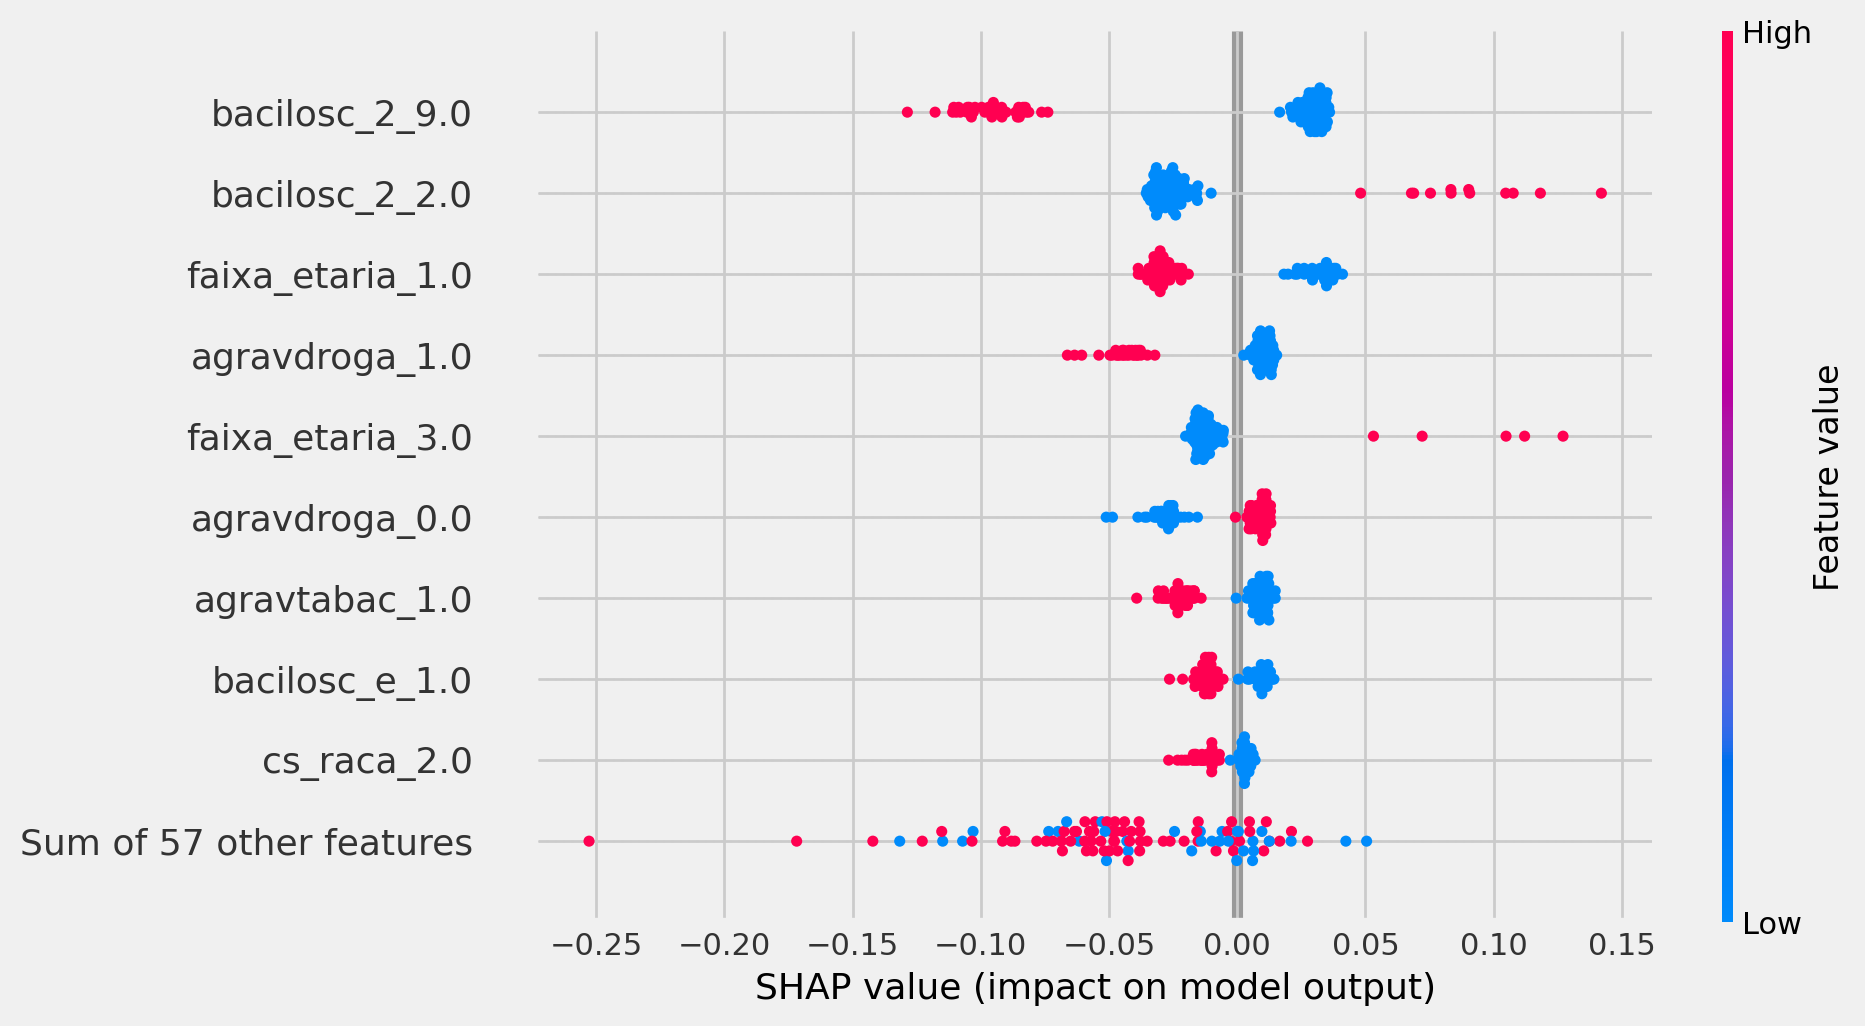

In [ ]:
import shap
import pandas as pd
import numpy as np

# =====================================================
# Seleciona um conjunto de fundo (background)
# =====================================================

background = shap.sample(X_train_tabpfn, 100, random_state=seed)

# =====================================================
# Cria o explicador SHAP
# =====================================================

explainer = shap.Explainer(
    tabpfn.predict_proba,
    background
)

# =====================================================
# Calcula os valores SHAP
# (use poucas amostras inicialmente para acelerar)
# =====================================================

X_explain = X_train_tabpfn.iloc[:100]

shap_values = explainer(X_explain)

# =====================================================
# Gráfico resumo
# =====================================================

shap.plots.beeswarm(shap_values[:, :, 1])

In [ ]:
importance = pd.DataFrame({
    "Variavel": X_explain.columns,
    "SHAP": np.abs(shap_values.values[:, :, 1]).mean(axis=0)
})

importance = (
    importance
    .sort_values("SHAP", ascending=False)
    .head(20)
)

print(importance)

            Variavel      SHAP
33    bacilosc_2_9.0  0.055589
31    bacilosc_2_2.0  0.034136
62  faixa_etaria_1.0  0.030632
47    agravdroga_1.0  0.019947
64  faixa_etaria_3.0  0.016683
46    agravdroga_0.0  0.016077
50    agravtabac_1.0  0.015004
23    bacilosc_e_1.0  0.011003
5        cs_raca_2.0  0.006787
53  escola_faixa_0.0  0.006348
1        cs_sexo_0.0  0.004766
43     benef_gov_0.0  0.004724
49    agravtabac_0.0  0.004487
2        cs_sexo_1.0  0.004238
24    bacilosc_e_2.0  0.003901
54  escola_faixa_1.0  0.003776
32    bacilosc_2_3.0  0.003537
38       pop_rua_1.0  0.003504
17    agravdiabe_0.0  0.003164
29    cultura_es_4.0  0.002697


In [ ]:
top20shap = importance.head(20)

print("\nTop 20 variáveis mais importantes:")
print(top20shap)


Top 20 variáveis mais importantes:
            Variavel      SHAP
33    bacilosc_2_9.0  0.055589
31    bacilosc_2_2.0  0.034136
62  faixa_etaria_1.0  0.030632
47    agravdroga_1.0  0.019947
64  faixa_etaria_3.0  0.016683
46    agravdroga_0.0  0.016077
50    agravtabac_1.0  0.015004
23    bacilosc_e_1.0  0.011003
5        cs_raca_2.0  0.006787
53  escola_faixa_0.0  0.006348
1        cs_sexo_0.0  0.004766
43     benef_gov_0.0  0.004724
49    agravtabac_0.0  0.004487
2        cs_sexo_1.0  0.004238
24    bacilosc_e_2.0  0.003901
54  escola_faixa_1.0  0.003776
32    bacilosc_2_3.0  0.003537
38       pop_rua_1.0  0.003504
17    agravdiabe_0.0  0.003164
29    cultura_es_4.0  0.002697


####Rodando modelo reduzido

In [ ]:
from tabpfn_client import TabPFNClassifier
from sklearn.metrics import roc_auc_score

# Seleciona as 20 variáveis mais importantes
top20_shap = importance.head(20)['Variavel'].tolist()

print("Top 20 variáveis:")
print(top20_shap)

# Conjunto de treino reduzido
X_train_top20shap = X_train_tabpfn[top20_shap]

# Novo modelo
tabpfn_top20_shap = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

# Ajuste
tabpfn_top20_shap.fit(X_train_top20shap, y_train_tabpfn)

# Probabilidades previstas no treino
y_proba_train_shap = tabpfn_top20_shap.predict_proba(X_train_top20shap)[:, 1]

Top 20 variáveis:
['bacilosc_2_9.0', 'bacilosc_2_2.0', 'faixa_etaria_1.0', 'agravdroga_1.0', 'faixa_etaria_3.0', 'agravdroga_0.0', 'agravtabac_1.0', 'bacilosc_e_1.0', 'cs_raca_2.0', 'escola_faixa_0.0', 'cs_sexo_0.0', 'benef_gov_0.0', 'agravtabac_0.0', 'cs_sexo_1.0', 'bacilosc_e_2.0', 'escola_faixa_1.0', 'bacilosc_2_3.0', 'pop_rua_1.0', 'agravdiabe_0.0', 'cultura_es_4.0']
00:04 Fitting... Done!
00:02 Predicting... Done!


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_novo = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

scores = cross_val_score(
    tabpfn_novo,
    X_train_top20shap,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

00:06 Fitting... Done!
00:02 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
00:06 Fitting... Done!
00:04 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
[0.69232814 0.79137137 0.66973777 0.67461021 0.68519533]
0.7026485621630909


In [ ]:
auc_cv_novo_tabpfn = scores.mean()

In [ ]:
auc_cv_novo_tabpfn

np.float64(0.7026485621630909)

In [ ]:
# Bases com variáveis selecionadas
X_train_novo = X_train[top20_shap].copy()
X_test_novo = X_test[top20_shap].copy()

# Unificando com a variável alvo
df_train_novo = pd.concat([X_train_novo, y_train], axis=1)
df_test_novo = pd.concat([X_test_novo, y_test], axis=1)

####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_tabpfn2boruta_rj_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_tabpfn2boruta_rj_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_tabpfn2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_tabpfn2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

### Retreino do Modelo

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train_novo, y_train)
predictions = clf.predict(X_test_novo)

00:06 Fitting... Done!
00:04 Predicting... Done!


In [ ]:
# Modelo TabPFN com configuração de ensemble
tabpfn_novo=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_novo = df_train.copy()
df_train_novo = (
    df_train_novo
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_novo)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_novo_tabpfn = df_train_novo.drop(columns = "cura")
y_train_tabpfn = df_train_novo.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_novo_tabpfn, y_train_tabpfn)


00:00 Fitting... \

00:04 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '9586dcc261944eaeadef354f6669e1fe'}),
                 ignore_pretraining_limits=True, random_state=42)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# ======================================
# Validação cruzada (somente treino)
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_cv = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

auc_scores = cross_val_score(
    tabpfn_cv,
    X_train_novo_tabpfn,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1  # recomendado para TabPFN
)

auc_cv_novo_tabpfn = auc_scores.mean()

print(f"AUC CV TabPFN: {auc_cv_novo_tabpfn:.4f}")
print(f"Desvio padrão: {auc_scores.std():.4f}")
print(f"AUC por fold: {auc_scores}")

00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... |

00:02 Predicting... Done!
00:00 Fitting... |

00:04 Fitting... Done!
00:00 Predicting... |

00:02 Predicting... Done!
00:00 Fitting... |

...

00:02 Predicting... Done!
00:00 Fitting... |

00:02 Fitting... Done!
00:00 Predicting... |

00:02 Predicting... Done!
00:00 Fitting... |

00:04 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
AUC CV TabPFN: 0.7026
Desvio padrão: 0.0451
AUC por fold: [0.69232814 0.79137137 0.66973777 0.67461021 0.68519533]


#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_novo_tabpfn = tabpfn.predict_proba(X_test_novo)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_novo_tabpfn = (y_prob_novo_tabpfn >= threshold).astype(int)

# Métricas
auc_novo_tabpfn = roc_auc_score(y_test, y_prob_novo_tabpfn)  # Continua usando probabilidade para o AUC

# Impressão
print(f'tabpfn_novo - ROC AUC: {auc_novo_tabpfn:.4f}')


00:03 Predicting... Done!
tabpfn_novo - ROC AUC: 0.7280


In [ ]:
tabpfn_novo.fit(X_train_novo_tabpfn, y_train_tabpfn)

y_prob_novo_tabpfn = tabpfn_novo.predict_proba(X_test_novo)[:, 1]
auc_novo_tabpfn = roc_auc_score(y_test, y_prob_novo_tabpfn)

print(f"AUC CV (treino): {auc_cv_novo_tabpfn:.4f}")
print(f"AUC Teste      : {auc_novo_tabpfn:.4f}")

00:00 Fitting... |

00:04 Fitting... Done!
00:00 Predicting... |

00:02 Predicting... Done!
AUC CV (treino): 0.7026
AUC Teste      : 0.7280


####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn_novo.pkl"

joblib.dump(tabpfn_novo, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn_novo.pkl


In [ ]:
joblib.dump(
    {
        "model_tabpfn_novo": tabpfn_novo,
        "auc_cv_tabpfn_novo": auc_cv_novo_tabpfn,
        "features": list(X_train_novo.columns)
    },
    caminho
)

['/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn_novo.pkl']

In [ ]:
data = joblib.load(caminho)

tabpfn_novo = data["model_tabpfn_novo"]
auc_cv_tabpfn_novo = data["auc_cv_tabpfn_novo"]
features_tabpfn = data["features"]

####Comparacao modelo completo e boruta - tabela

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_treino_processados1_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/dados_teste_processados1_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
import joblib
import pandas as pd

# Modelo completo
data_full = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn.pkl"
)

# Modelo Boruta/Top Features
data_novo = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn_novo.pkl"
)

auc_cv_tabpfn = data_full["auc_cv_tabpfn"]
auc_cv_tabpfn_novo = data_novo["auc_cv_tabpfn_novo"]

comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Boruta"],
    "AUC-CV": [auc_cv_tabpfn, auc_cv_tabpfn_novo]
})

print(comparacao)

if auc_cv_tabpfn > auc_cv_tabpfn_novo:
    print(f"\n🏆 Melhor modelo: Base Completa (AUC-CV = {auc_cv_tabpfn:.4f})")
elif auc_cv_tabpfn_novo > auc_cv_tabpfn:
    print(f"\n🏆 Melhor modelo: Boruta (AUC-CV = {auc_cv_tabpfn_novo:.4f})")
else:
    print("\n🤝 Os dois modelos possuem o mesmo AUC-CV.")

          Modelo    AUC-CV
0  Base Completa  0.698496
1         Boruta  0.702649

🏆 Melhor modelo: Boruta (AUC-CV = 0.7026)


# Comparando todos os modelos

In [ ]:
!pip install tabpfn-client
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score
from tabpfn_client import TabPFNClassifier # Added import for TabPFNClassifier

rf = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_rf.pkl")
xgb = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_xgb.pkl")
lgb = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_lgb.pkl")
cat = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat.pkl")
tabpfn = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn.pkl")
rf_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_rf_novo.pkl")
lgb_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_lgb_novo.pkl")
xgb_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_xgb_novo.pkl")
cat_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat_novo.pkl")
tabpfn_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_tabpfn_novo.pkl")

In [ ]:
# ===============================
# SEEDS DOS MODELOS
# ===============================

modelos = {
    "RandomForest": rf['model_rf'],
    "LGBM": lgb['model_lgb'],
    "XGBoost": xgb['model_xgb'],
    "CatBoost": cat['model_cat'],
    "TabPFN": tabpfn['model_tabpfn'],
    "RandomForest_novo": rf_novo['model_rf_novo'],
    "LGBM_novo": lgb_novo['model_lgb_novo'],
    "XGBoost_novo": xgb_novo['model_xgb_novo'],
    "CatBoost_novo": cat_novo['model_cat_novo'],
    "TabPFN_novo": tabpfn_novo['model_tabpfn_novo'],
}

for nome, modelo in modelos.items():
    try:
        params = modelo.get_params()

        seed = (
            params.get('random_state')
            or params.get('seed')
            or params.get('random_seed')
        )

        print(f"{nome}: {seed}")

    except Exception as e:
        print(f"{nome}: não foi possível obter a seed ({e})")

RandomForest: 42
LGBM: 42
XGBoost: 42
CatBoost: 42
TabPFN: 42
RandomForest_novo: 42
LGBM_novo: 42
XGBoost_novo: 42
CatBoost_novo: 42
TabPFN_novo: 42


In [ ]:
# ============================================================
# CONTAGEM REAL DE VARIÁVEIS BORUTA E AUDITORIA DOS MODELOS
# ============================================================

import pandas as pd

TARGET = "cura"

# ------------------------
# Bases pós-Boruta
# ------------------------

paths_boruta = {
    "RandomForest_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_rf2boruta_rj_2015_2025.csv",

    "LGBM_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_lgb2boruta_rj_2015_2025.csv",

    "XGBoost_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_xgb2boruta_rj_2015_2025.csv",

    "CatBoost_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_cat2boruta_rj_2015_2025.csv",

    "TabPFN_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_tabpfn2boruta_rj_2015_2025.csv"
}

# ------------------------
# Modelos novos
# ------------------------

modelos_novos = {
    "RandomForest_novo": rf_novo['model_rf_novo'],
    "LGBM_novo": lgb_novo['model_lgb_novo'],
    "XGBoost_novo": xgb_novo['model_xgb_novo'],
    "CatBoost_novo": cat_novo['model_cat_novo'],
    "TabPFN_novo": tabpfn_novo['model_tabpfn_novo']
}

audit_boruta = {}

for nome, caminho in paths_boruta.items():

    df_boruta = pd.read_csv(caminho)

    # Remove desfecho
    features_boruta = [c for c in df_boruta.columns if c != TARGET]

    n_features_boruta = len(features_boruta)

    modelo = modelos_novos[nome]

    # Recupera features efetivamente usadas pelo modelo
    try:

        if hasattr(modelo, "feature_names_in_"):
            features_modelo = list(modelo.feature_names_in_)

        elif hasattr(modelo, "feature_names_"):
            features_modelo = list(modelo.feature_names_)

        else:
            features_modelo = []

        n_features_modelo = len(features_modelo)

        faltantes = sorted(
            list(set(features_boruta) - set(features_modelo))
        )

        extras = sorted(
            list(set(features_modelo) - set(features_boruta))
        )

        status = (
            "OK"
            if len(faltantes) == 0 and len(extras) == 0
            else "DIVERGENTE"
        )

    except Exception as e:

        n_features_modelo = None
        faltantes = []
        extras = []
        status = f"Erro: {e}"

    audit_boruta[nome] = {
        "N_Boruta": n_features_boruta,
        "N_Modelo": n_features_modelo,
        "Status": status,
        "Faltantes": faltantes,
        "Extras": extras
    }

# ------------------------
# Mostrar auditoria
# ------------------------

print("\n" + "="*60)
print("AUDITORIA BORUTA × MODELO")
print("="*60)

for nome, info in audit_boruta.items():

    print(f"\n{nome}")
    print(f"Variáveis Boruta : {info['N_Boruta']}")
    print(f"Variáveis Modelo : {info['N_Modelo']}")
    print(f"Status           : {info['Status']}")

    if len(info['Faltantes']) > 0:
        print(f"\nFaltantes ({len(info['Faltantes'])}):")
        print(info['Faltantes'])

    if len(info['Extras']) > 0:
        print(f"\nExtras ({len(info['Extras'])}):")
        print(info['Extras'])


AUDITORIA BORUTA × MODELO

RandomForest_novo
Variáveis Boruta : 19
Variáveis Modelo : 19
Status           : OK

LGBM_novo
Variáveis Boruta : 18
Variáveis Modelo : 18
Status           : OK

XGBoost_novo
Variáveis Boruta : 31
Variáveis Modelo : 31
Status           : OK

CatBoost_novo
Variáveis Boruta : 23
Variáveis Modelo : 23
Status           : OK

TabPFN_novo
Variáveis Boruta : 20
Variáveis Modelo : 0
Status           : DIVERGENTE

Faltantes (20):
['agravdiabe_0.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0', 'bacilosc_2_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'benef_gov_0.0', 'cs_raca_2.0', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cultura_es_4.0', 'escola_faixa_0.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_3.0', 'pop_rua_1.0']


In [ ]:
resultados_cv = [

    {
        "Modelo": "RandomForest",
        "AUC_CV": rf["auc_cv_rf"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "LGBM",
        "AUC_CV": lgb["auc_cv_lgb"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "XGBoost",
        "AUC_CV": xgb["auc_cv_xgb"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "CatBoost",
        "AUC_CV": cat["auc_cv_cat"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "TabPFN",
        "AUC_CV": tabpfn["auc_cv_tabpfn"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "RandomForest_novo",
        "AUC_CV": rf_novo["auc_cv_rf_novo"],
        "N_Features": audit_boruta["RandomForest_novo"]["N_Boruta"]
    },

    {
        "Modelo": "LGBM_novo",
        "AUC_CV": lgb_novo["auc_cv_lgb_novo"],
        "N_Features": audit_boruta["LGBM_novo"]["N_Boruta"]
    },

    {
        "Modelo": "XGBoost_novo",
        "AUC_CV": xgb_novo["auc_xgb_novo"],
        "N_Features": audit_boruta["XGBoost_novo"]["N_Boruta"]
    },

    {
        "Modelo": "CatBoost_novo",
        "AUC_CV": cat_novo["auc_cv_cat_novo"],
        "N_Features": audit_boruta["CatBoost_novo"]["N_Boruta"]
    },

    {
        "Modelo": "TabPFN_novo",
        "AUC_CV": tabpfn_novo["auc_cv_tabpfn_novo"],
        "N_Features": audit_boruta["TabPFN_novo"]["N_Boruta"]
    }
]

df_cv = (
    pd.DataFrame(resultados_cv)
      .sort_values("AUC_CV", ascending=False)
      .reset_index(drop=True)
)

print("\n")
print("=" * 60)
print("RANKING FINAL DOS MODELOS - AUC DA VALIDAÇÃO CRUZADA")
print("=" * 60)
print(df_cv)




RANKING FINAL DOS MODELOS - AUC DA VALIDAÇÃO CRUZADA
              Modelo    AUC_CV  N_Features
0               LGBM  0.755509          58
1            XGBoost  0.755509          58
2           CatBoost  0.755509          58
3      CatBoost_novo  0.754795          23
4       XGBoost_novo  0.754133          31
5       RandomForest  0.750111          58
6          LGBM_novo  0.745790          18
7  RandomForest_novo  0.745299          19
8        TabPFN_novo  0.702649          20
9             TabPFN  0.698496          58
